In [849]:
import sys
import matplotlib.pyplot as plt
import numpy as np
import importlib
import os
import cmcrameri.cm as cmc

from scipy.signal import stft
from scipy.signal import windows

import superlets_package.auxiliar_functions as aux
import superlets_package.cwt as cwt
import superlets_package.superlets_emg as superlet

sys.path.insert(0, '..')
print(sys.path)

['..', '..', '..', '..', '..', '..', '..', '..', '..', '..', '..', '..', '..', '..', '..', '..', '/Applications/PyCharm.app/Contents/plugins/python/helpers-pro/jupyter_debug', '/Applications/PyCharm.app/Contents/plugins/python/helpers/pydev', '..', '/Users/neuralrehabilitationgroup/PycharmProjects/Superlets-Marina', '/Users/neuralrehabilitationgroup/PycharmProjects/SingularSuperletPY', '/opt/anaconda3/envs/Superlets-Marina/lib/python38.zip', '/opt/anaconda3/envs/Superlets-Marina/lib/python3.8', '/opt/anaconda3/envs/Superlets-Marina/lib/python3.8/lib-dynload', '', '/opt/anaconda3/envs/Superlets-Marina/lib/python3.8/site-packages', '/opt/anaconda3/envs/Superlets-Marina/lib/python3.8/site-packages/setuptools/_vendor']


In [850]:
importlib.reload(superlet)

<module 'superlets_package.superlets_emg' from '/Users/neuralrehabilitationgroup/PycharmProjects/Superlets-Marina/superlets_package/superlets_emg.py'>

In [851]:
importlib.reload(cwt)

<module 'superlets_package.cwt' from '/Users/neuralrehabilitationgroup/PycharmProjects/Superlets-Marina/superlets_package/cwt.py'>

In [852]:
importlib.reload(aux)

<module 'superlets_package.auxiliar_functions' from '/Users/neuralrehabilitationgroup/PycharmProjects/Superlets-Marina/superlets_package/auxiliar_functions.py'>

In [853]:
fontsize_title = 10
fontsize_subtitle = 16
fontsize_ticks = 12
fontsize_labels = 14
fontsize_legend = 14

# Create simulated signals

### Signal parameters

In [854]:
fs = 1024
signal_duration = 3
t = np.linspace(0, signal_duration, signal_duration * fs)

### Baseline noise

In [855]:
np.random.seed(10)
noise = np.random.normal(0, 0.01, len(t))

### Burst parameters

In [856]:
burst_duration = 0.5
burst_start = 1
real_t_onset = burst_start
real_t_offset = burst_start + burst_duration

start_idx = int(real_t_onset * fs)
end_idx = int(real_t_offset * fs)

### De Luca method to create burst with a known frequency

MNF ideal = 115.72429511777993
MNF analytic = 123.27802997905654


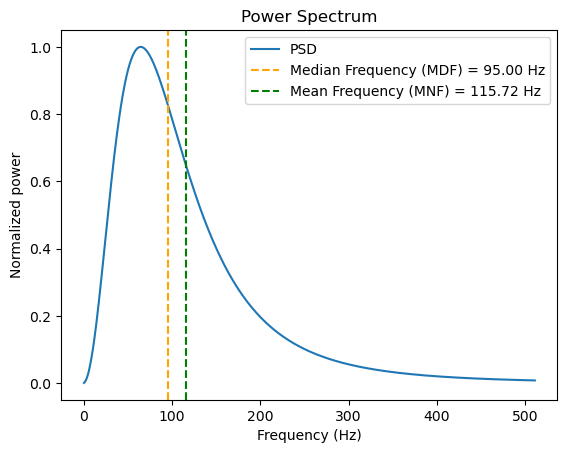

In [857]:
[_, PdeLuca, burst, MNF_ideal, MNF_analytic] = aux.fdeluca(120, 60, fs, burst_duration, plot=False)
print(f'MNF ideal = {MNF_ideal}')
print(f'MNF analytic = {MNF_analytic}')

### Save the signal

In [858]:
save = True

folder_out = f'/Users/neuralrehabilitationgroup/PycharmProjects/Superlets-Marina/RESULTS/PAPER/{burst_duration}S'
new_folder_path = os.path.join(folder_out, str(round(MNF_ideal, 2)) + ' Hz')

if save:
    os.makedirs(new_folder_path, exist_ok=True)

filename = os.path.join(new_folder_path, str(round(MNF_ideal, 2)) + ' Hz.npy')

if os.path.exists(filename):
    burst_signal = np.load(filename)
else:
    burst_signal = noise.copy()
    burst_signal[int(burst_start * fs):int(burst_start * fs + len(burst))] = burst
    
    np.save(filename, burst_signal)

### Signal visualization

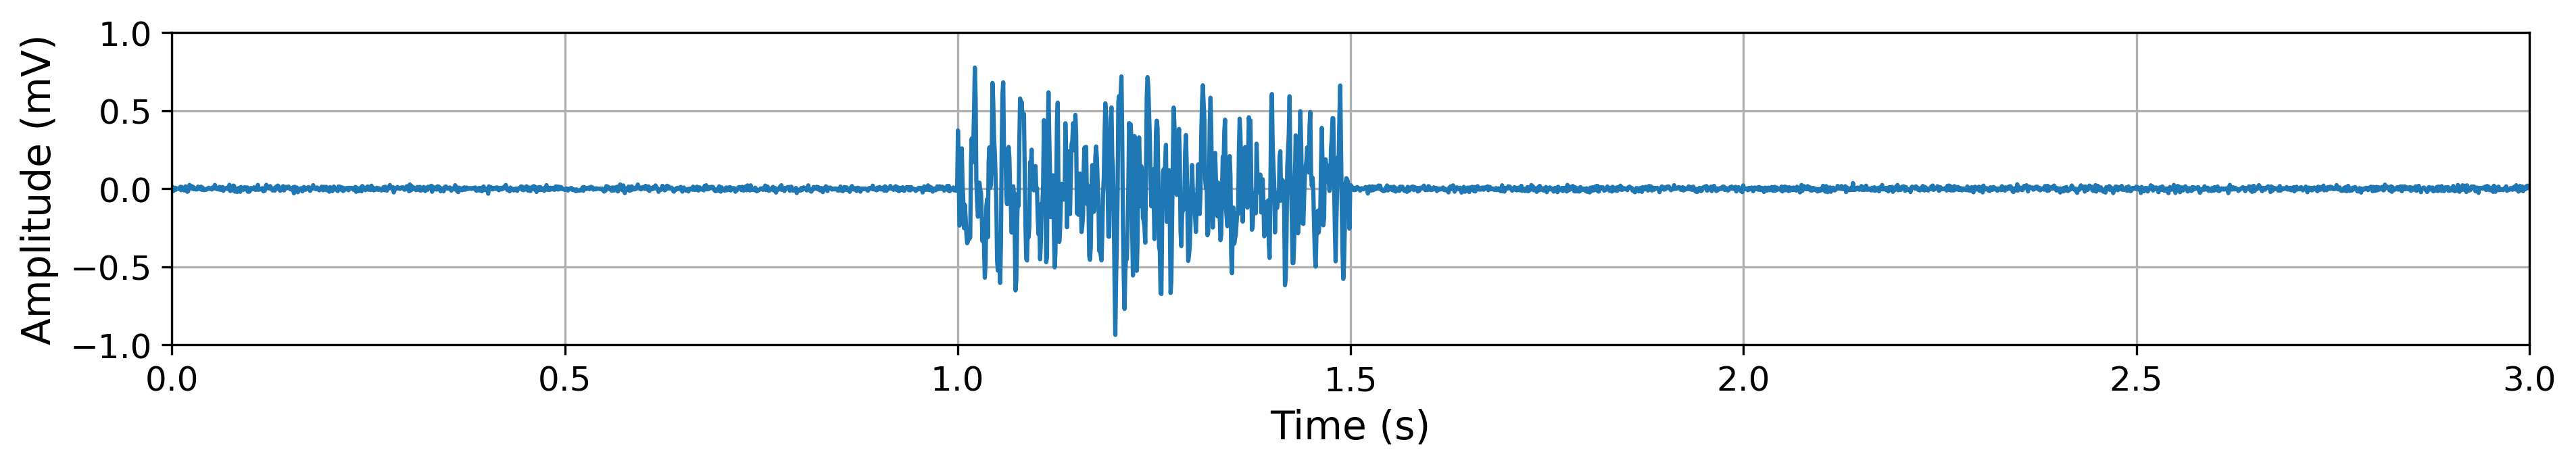

In [859]:
fig, ax = plt.subplots(figsize=(15, 2), dpi=300)
ax.set_xlabel("Time (s)", fontsize=fontsize_labels)
ax.set_ylabel("Amplitude (mV)", fontsize=fontsize_labels)
ax.set_xlim(0,3)
ax.set_ylim(-1,1)

ax.plot(np.linspace(0, len(burst_signal)/fs, len(burst_signal)), burst_signal)

ax.tick_params(axis='both', labelsize=fontsize_ticks)
ax.grid(True)

if save:
    fig.savefig(os.path.join(new_folder_path,"emg.png"), dpi=300, bbox_inches="tight")
    

# Definition of the frequency of interest

In [860]:
freqs = np.linspace(10,500,int(fs/2))

### Add noise to the signal with a particular value for SNR

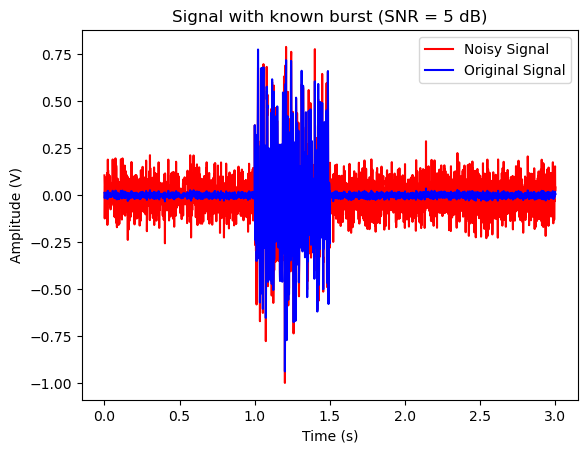

6.568898145589754 dB


In [861]:
SNR = 5
signal_5, xn = aux.add_noise(burst_signal, SNR, fs, plot = True)
real_snr = aux.compute_snr(signal_5, xn)
print(f'{real_snr} dB')

# Continuous Wavelet Transform

In [862]:
plot_tf_representation = False
plot_responses = False

In [863]:
# params_wavelet = [1, 3, 9, 27, 81, 200] # FOR RESOLUTION
params_wavelet = [100, 130, 230]

In [864]:
f_min = 10
f_max = 300

In [865]:
if plot_tf_representation:
    fig, ax = plt.subplots(ncols=len(params_wavelet), figsize=(18,5), dpi=300, sharey=True, sharex=True)
if plot_responses:
    fig_2, (ax_2_1, ax_2_2) = plt.subplots(1, 2, figsize=(18, 5))  
    
mae_wavelet_f = []
std_wavelet_f = []

mae_wavelet_t = []
std_wavelet_t = []

for i, c in enumerate(params_wavelet):
    print(f'{i+1} parameter')
    wavelet = f'cmor{c}-1.0'
    
    cwtmatr, f_cwt, physical_freqs = cwt.wavelet_transform(signal_5,wavelet,freqs,fs)
    scalogram_cwt = np.abs(cwtmatr)**2
    
    if plot_tf_representation:     
        # Define limits for the TF power representations
        mask_cwt = (f_cwt >= f_min) & (f_cwt <= f_max)
        
        pcm = ax[i].pcolormesh(t, f_cwt[mask_cwt], scalogram_cwt[mask_cwt,:], shading='gouraud', cmap=cmc.batlow)
        
        ax[i].set_title(f'c={c}', fontsize=fontsize_subtitle)
        if i == 0:
            ax[i].set_ylabel('Frequency (Hz)', fontsize=fontsize_labels)
        else:
            ax[i].set_ylabel('')
        
        ax[i].set_ylim(f_cwt[0], f_max)
        ax[i].tick_params(axis='x', labelbottom=False, bottom=True) 
   
    # Energy in time is given directly by the scalogram
    first_indices = []
    last_indices = []
    
    # We compute one t_onset and t_offset for each frequency bin in the scalogram (that's why we don´t do energy_t = np.sum(scalogram_cwt, axis=0))
    for row in scalogram_cwt:
        first_index, last_index = aux.find_plateau_region(row, burst_start, burst_duration, t, fs, plot_results=False)
        first_indices.append(first_index)
        last_indices.append(last_index)
        
    t_onset = t[first_indices]
    t_offset = t[last_indices]
    
    # Compute the instantaneous frequency
    instant_freq = np.sum(scalogram_cwt * f_cwt[:, np.newaxis], axis=0) / np.sum(scalogram_cwt, axis=0)
    
    instant_mean_freq_burst = instant_freq[start_idx:end_idx]
    
    if plot_responses:
        ax_2_1.plot(t, instant_freq, label=f"c={c}")
        ax_2_1.set_xlabel("Time (s)")
        ax_2_1.set_ylabel("Frequency (Hz)")
        ax_2_1.legend()
        ax_2_1.grid(True)
        ax_2_1.axhline(MNF_ideal, color='red', linestyle='--')
        ax_2_1.set_title("Instantaneous frequency")
        
        ax_2_2.plot(t,  np.sum(scalogram_cwt, axis=0), label=f"c={c}")
        ax_2_2.set_xlabel("Time (s)")
        ax_2_2.set_ylabel("Energy (mV²)")
        ax_2_2.legend()
        ax_2_2.grid(True)
        ax_2_2.axvline(real_t_onset, color='red', linestyle='--')
        ax_2_2.axvline(real_t_offset, color='red', linestyle='--')
        ax_2_2.set_title("Energy over time")
        
    # Compute MAE in frequency
    print(f'Estimated mean frequency: {np.mean(instant_mean_freq_burst)} Hz')
    mae_f, std_f = aux.calculate_mae(instant_mean_freq_burst, MNF_ideal)
    mae_wavelet_f.append(mae_f)
    std_wavelet_f.append(std_f)
    
    # Compute MAE in time
    print(f'Estimated onset = {np.mean(t_onset)} s, offset = {np.mean(t_offset)} s')
    mae_t, std_t = aux.calculate_mae((t_onset,t_offset), (real_t_onset,real_t_offset))
    mae_wavelet_t.append(mae_t)
    std_wavelet_t.append(std_t)
    print('---------------------------------------------------------------------------')
    
        
if plot_tf_representation: 
    cbar = fig.colorbar(pcm, ax=ax, orientation='horizontal', pad=0.15, shrink=0.1)
    
    cbar.set_label('Power (mV²)', rotation=0, labelpad=15, fontsize=fontsize_labels)
        
# if save:
#     fig.savefig(os.path.join(new_folder_path,f'scalogram_cwt_{SNR}.png'), dpi=300, bbox_inches="tight")
#     fig_2.savefig(os.path.join(new_folder_path,f'responses_cwt_{SNR}.png'), dpi=300, bbox_inches="tight")
    

1 parameter
Estimated mean frequency: 123.28765982342043 Hz
Estimated onset = 0.6255793868039726 s, offset = 1.8911299759850209 s
---------------------------------------------------------------------------
2 parameter
Estimated mean frequency: 123.8929881584024 Hz
Estimated onset = 0.6230894863236731 s, offset = 1.8937744220123736 s
---------------------------------------------------------------------------
3 parameter
Estimated mean frequency: 124.93393750342277 Hz
Estimated onset = 0.6200329188375122 s, offset = 1.893604612707587 s
---------------------------------------------------------------------------


In [866]:
mae_wavelet_f

[9.73397429073465, 10.11340054750206, 10.870511072269041]

In [867]:
mae_wavelet_t

[0.4178981551204819, 0.41926744138717026, 0.41982297856968415]

# Superlet Transform

In [868]:
# params_superlet = [[1,1,3,5,8,10],[1,1,1,2,4,4],[2,3,9,50,160,200]] # FOR RESOLUTION
params_superlet = [[2,3,6],[3,4,7],[220,250,300]]

In [869]:
if plot_tf_representation:
    fig, ax = plt.subplots(ncols=len(params_wavelet), figsize=(18,5), dpi=300, sharey=True, sharex=True)
if plot_responses:
    fig_2, (ax_2_1, ax_2_2) = plt.subplots(1, 2, figsize=(18, 5))  
    
mae_superlet_f = []
std_superlet_f = []

mae_superlet_t = []
std_superlet_t = []


for (i, (base_cycle, min_order, max_order)) in enumerate(zip(*params_superlet)):
    print(f'{i+1} parameter')

    # This implementation gives the scalogram directly
    _, scalogram_slt = superlet.adaptive_superlet_transform(signal_5, freqs, sampling_freq=fs,
                                                         base_cycle=base_cycle, min_order=min_order,
                                                         max_order=max_order, mode="mul")
    
    if plot_tf_representation:
        mask_slt = (freqs >= f_min) & (freqs <= f_max)
        im = ax[i].pcolormesh(t, freqs[mask_slt], scalogram_slt[mask_slt,:], shading='auto', cmap=cmc.batlow)
        
        # For a faster representation
        # im = ax[i].imshow(scalogram_slt[mask_slt,:], aspect='auto', cmap=cmc.batlow, interpolation="none", origin="lower",extent=[0, len(signal_5)/fs, freqs[mask_slt][0], freqs[mask_slt][-1]])
        
        ax[i].set_title(f"$c_1$: {base_cycle}, o: {min_order}-{max_order}", fontsize=fontsize_subtitle)
        ax[i].set_xlabel("Time (s)", fontsize=fontsize_labels)
        if i == 0:
            ax[i].set_ylabel("Frequency (Hz)", fontsize=fontsize_labels)
        else:
            ax[i].set_ylabel("")
        ax[i].set_ylim(f_min, f_max)
        ax[i].grid(False)
   
    # Energy in time is given directly by the scalogram
    first_indices = []
    last_indices = []
    
    # We compute one t_onset and t_offset for each frequency bin in the scalogram (that's why we don´t do energy_t = np.sum(scalogram_cwt, axis=0))

    for row in scalogram_slt:
        first_index, last_index = aux.find_plateau_region(row, burst_start, burst_duration, t, fs, plot_results=False)
        first_indices.append(first_index)
        last_indices.append(last_index)
        
    t_onset = t[first_indices]
    t_offset = t[last_indices]
    
    # Compute the instantaneous frequency
    instant_freq = np.sum(scalogram_slt * freqs[:, np.newaxis], axis=0) / np.sum(scalogram_slt, axis=0)
    
    instant_mean_freq_burst = instant_freq[start_idx:end_idx]
    
    if plot_responses:
        ax_2_1.plot(t, instant_freq, label=f"$c_1$: {base_cycle}, o: {min_order}-{max_order}")
        ax_2_1.set_xlabel("Time (s)")
        ax_2_1.set_ylabel("Frequency (Hz)")
        ax_2_1.legend()
        ax_2_1.grid(True)
        ax_2_1.axhline(MNF_ideal, color='red', linestyle='--')
        ax_2_1.set_title("Instantaneous frequency")
        
        ax_2_2.plot(t,  np.sum(scalogram_slt, axis=0), label=f"c={c}")
        ax_2_2.set_xlabel("Time (s)")
        ax_2_2.set_ylabel("Energy (mV²)")
        ax_2_2.legend()
        ax_2_2.grid(True)
        ax_2_2.axvline(real_t_onset, color='red', linestyle='--')
        ax_2_2.axvline(real_t_offset, color='red', linestyle='--')
        ax_2_2.set_title("Energy over time")
        
    # Compute MAE in frequency
    print(f'Estimated mean frequency: {np.mean(instant_mean_freq_burst)} Hz')
    mae_f, std_f = aux.calculate_mae(instant_mean_freq_burst, MNF_ideal)
    mae_superlet_f.append(mae_f)
    std_superlet_f.append(std_f)
    
    # Compute MAE in time
    print(f'Estimated onset = {np.mean(t_onset)} s, offset = {np.mean(t_offset)} s')
    mae_t, std_t = aux.calculate_mae((t_onset,t_offset), (real_t_onset,real_t_offset))
    mae_superlet_t.append(mae_t)
    std_superlet_t.append(std_t)
    print('---------------------------------------------------------------------------')
    
        
if plot_tf_representation: 
    cbar = fig.colorbar(pcm, ax=ax, orientation='horizontal', pad=0.15, shrink=0.1)
    
    cbar.set_label('Power (mV²)', rotation=0, labelpad=15, fontsize=fontsize_labels)
        
# if save:
#     fig.savefig(os.path.join(new_folder_path,f'scalogram_cwt_{SNR}.png'), dpi=300, bbox_inches="tight")
#     fig_2.savefig(os.path.join(new_folder_path,"responses_cwt_5.png"), dpi=300, bbox_inches="tight")
    

1 parameter
Estimated mean frequency: 124.1261954606042 Hz
Estimated onset = 0.7297106500325627 s, offset = 1.7925184691468576 s
---------------------------------------------------------------------------
2 parameter
Estimated mean frequency: 125.30967527339374 Hz
Estimated onset = 0.7083337573266036 s, offset = 1.8197871723380004 s
---------------------------------------------------------------------------
3 parameter
Estimated mean frequency: 130.68134387780168 Hz
Estimated onset = 0.6134523312845979 s, offset = 1.9437422409231515 s
---------------------------------------------------------------------------


In [870]:
mae_superlet_f

[9.49712058936728, 9.585380155613802, 14.957048760021758]

In [871]:
mae_superlet_t

[0.33328256013920543, 0.346128920241778, 0.4334083589425269]

# STFT

In [872]:
# windows_ms = [770,800,960,900,100,200] # FOR RESOLUTION
windows_ms = [24, 634, 986]

In [873]:
if plot_tf_representation:
    fig, ax = plt.subplots(ncols=len(windows_ms), figsize=(18,5), dpi=300, sharey=True, sharex=True)
if plot_responses:
    fig_2, (ax_2_1, ax_2_2) = plt.subplots(1, 2, figsize=(18, 5))  

mae_stft_f = []
std_stft_f = []

mae_stft_t = []
std_stft_t = []

cv_stft = []

total_time = []
total_freq = []

for i, w in enumerate(windows_ms):
    window = windows.blackman(w)

    nfft = 2 * (len(freqs))

    f_stft, t_stft, Zxx = stft(signal_5, fs=fs, window='blackman', nperseg=w, noverlap=w-1, nfft=nfft, detrend=False, return_onesided=True, boundary='zeros', padded=True, axis=-1, scaling='spectrum')

    spectrogram = np.abs(Zxx) ** 2
    
    if plot_tf_representation:
        mask_stft = f_stft <= f_max
        
        im = ax[i].pcolormesh(t_stft, f_stft[mask_stft], spectrogram[mask_stft, :], shading="auto", cmap=cmc.batlow)
    
        ax[i].set_title(f'W = {w * 1000 // fs} ms', fontsize=fontsize_subtitle)
        ax[i].set_xlabel("Time (s)", fontsize=fontsize_labels)
    
        if i == 0:
            ax[i].set_ylabel("Frequency (Hz)", fontsize=fontsize_labels)
        else:
            ax[i].set_ylabel("")
    
        ax[i].set_ylim(f_min, f_max)
        ax[i].grid(False)

    instant_freq = np.sum(spectrogram * f_stft[:, np.newaxis], axis=0) / np.sum(spectrogram, axis=0)    
    energia_temporal = spectrogram
    
    first_indices = []
    last_indices = []
    
    for row in energia_temporal:
        first_index, last_index = aux.find_plateau_region(row, burst_start, burst_duration, t_stft, fs, plot_results=False)
        first_indices.append(first_index)
        last_indices.append(last_index)
    
    t_onset = t_stft[first_indices]
    t_offset = t_stft[last_indices]

    instant_mean_freq_burst = instant_freq[start_idx:end_idx]

    if plot_responses:
        ax_2_1.plot(t_stft, instant_freq, label=f'W={w * 1000 // fs} ms')
        ax_2_1.set_xlabel("Time (s)")
        ax_2_1.set_ylabel("Frequency (Hz)")
        ax_2_1.legend()
        ax_2_1.grid(True)
        ax_2_1.set_title("Instantaneous frequency")
        
        ax_2_2.plot(t_stft,  np.sum(spectrogram, axis=0), label=f'W={w * 1000 // fs} ms')
        ax_2_2.set_xlabel("Time (s)")
        ax_2_2.set_ylabel("Energy (V²)")
        ax_2_2.legend()
        ax_2_2.grid(True)
        ax_2_2.set_title("Energy over time")

    #MAE in frequency
    print(f'Estimated mean frequency: {np.mean(instant_mean_freq_burst)} Hz')
    mae_f, std_f = aux.calculate_mae(instant_mean_freq_burst, MNF_ideal)
    mae_stft_f.append(mae_f)
    std_stft_f.append(std_f)
    
    #MAE in time
    print(f'Estimated onset = {np.mean(t_onset)} s, offset = {np.mean(t_offset)} s')
    mae_t, std_t = aux.calculate_mae((t_onset,t_offset), (real_t_onset,real_t_offset))
    mae_stft_t.append(mae_t)
    std_stft_t.append(std_t)
    print('---------------------------------------------------------------------------')

if plot_tf_representation:
    cbar = fig.colorbar(pcm, ax=ax, orientation='horizontal', pad=0.15, shrink=0.1)
    cbar.set_label('Power (V²)', rotation=0, labelpad=15)
    
# if save:
#     fig.savefig(os.path.join(new_folder_path,f'scalogram_stft_{SNR}.png"), dpi=300, bbox_inches="tight")'))
#     fig_2.savefig(os.path.join(new_folder_path,"response_stft_15.png"), dpi=300, bbox_inches="tight")

Estimated mean frequency: 133.63893837886945 Hz
Estimated onset = 0.7023597404970761 s, offset = 1.8306929976851851 s
---------------------------------------------------------------------------
Estimated mean frequency: 124.32974854311263 Hz
Estimated onset = 0.7119921113547758 s, offset = 1.8165966130604287 s
---------------------------------------------------------------------------
Estimated mean frequency: 124.79825513955478 Hz
Estimated onset = 0.6733008193226121 s, offset = 1.856016995614035 s
---------------------------------------------------------------------------


In [874]:
mae_stft_f

[31.315278280937484, 8.605453425332684, 9.073960021774855]

In [875]:
mae_stft_t

[0.31933688931530213, 0.3540086653265107, 0.37907662493908384]

# Only first time

In [876]:
MAES_f = {'stft': [], 'wavelet': [], 'superlet': [], 'std_stft': [], 'std_wavelet': [], 'std_superlet': []}

In [877]:
MAES_f['wavelet'].append(mae_wavelet_f)
MAES_f['stft'].append(mae_stft_f)
MAES_f['superlet'].append(mae_superlet_f)
MAES_f['std_wavelet'].append(std_wavelet_f)
MAES_f['std_stft'].append(std_stft_f)
MAES_f['std_superlet'].append(std_superlet_f)

In [878]:
MAES_t = {'stft': [], 'wavelet': [], 'superlet': [], 'std_stft': [], 'std_wavelet': [], 'std_superlet': []}

In [879]:
MAES_t['wavelet'].append(mae_wavelet_t)
MAES_t['stft'].append(mae_stft_t)
MAES_t['superlet'].append(mae_superlet_t)
MAES_t['std_wavelet'].append(std_wavelet_t)
MAES_t['std_stft'].append(std_stft_t)
MAES_t['std_superlet'].append(std_superlet_t)

# We repeat everything with a different SNR

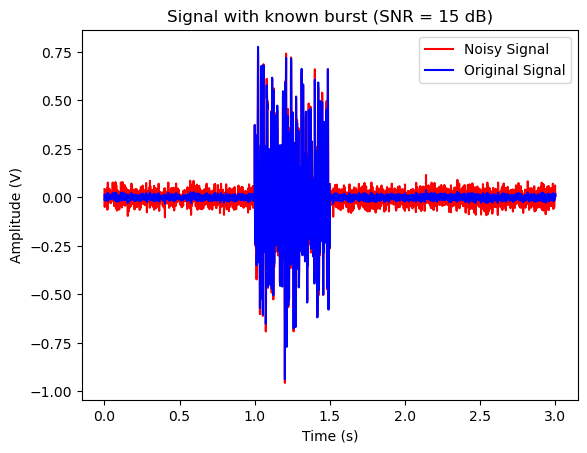

15.396890281791055 dB


In [880]:
SNR = 15
signal_15, xn = aux.add_noise(burst_signal, SNR, fs, plot = True)
real_snr = aux.compute_snr(signal_15, xn)
print(f'{real_snr} dB')

# Continuous Wavelet Transform

In [881]:
plot_tf_representation = True
plot_responses = True

Estimated mean frequency: 116.81572332679349 Hz
Estimated onset = 0.8482489925919896 s, offset = 1.664115923152068 s
---------------------------------------------------------------------------
Estimated mean frequency: 117.38019015061187 Hz
Estimated onset = 0.8476708777678281 s, offset = 1.6615058205796158 s
---------------------------------------------------------------------------
Estimated mean frequency: 118.36226335543999 Hz
Estimated onset = 0.8480085884076849 s, offset = 1.658350038668186 s
---------------------------------------------------------------------------


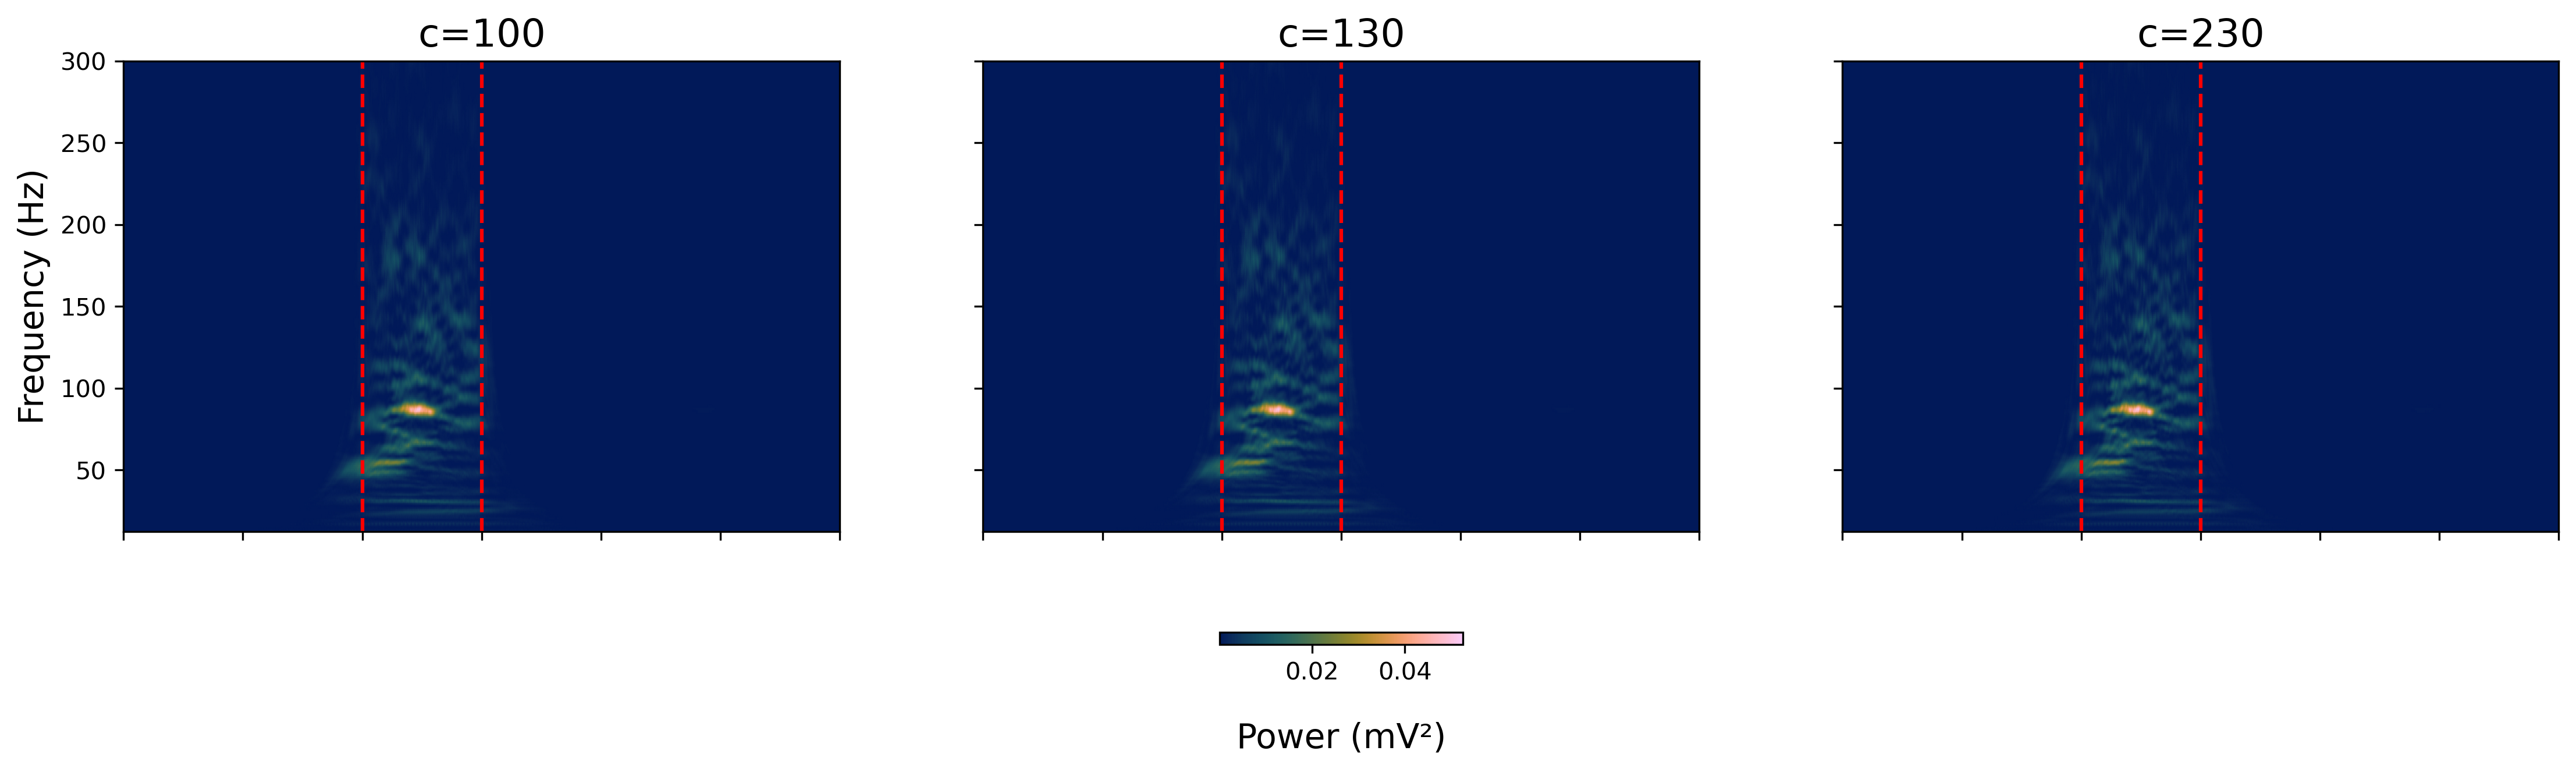

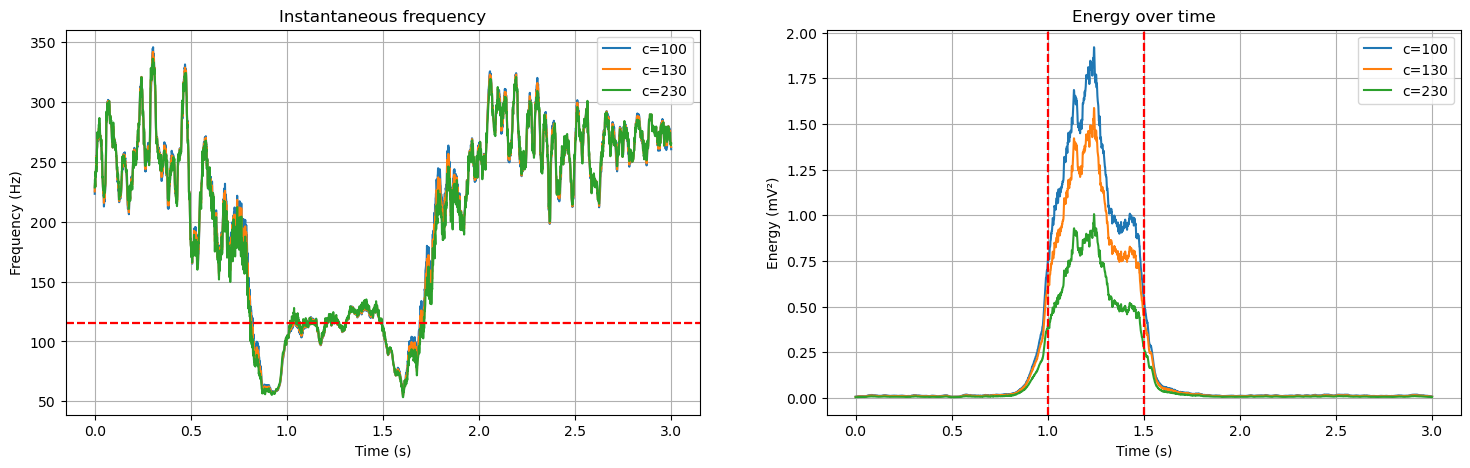

In [882]:
if plot_tf_representation:
    fig, ax = plt.subplots(ncols=len(params_wavelet), figsize=(18,5), dpi=300, sharey=True, sharex=True)
if plot_responses:
    fig_2, (ax_2_1, ax_2_2) = plt.subplots(1, 2, figsize=(18, 5))  
    
mae_wavelet_f = []
std_wavelet_f = []

mae_wavelet_t = []
std_wavelet_t = []

for i, c in enumerate(params_wavelet):
    wavelet = f'cmor{c}-1.0'
    
    cwtmatr, f_cwt, physical_freqs = cwt.wavelet_transform(signal_15,wavelet,freqs,fs)
    scalogram_cwt = np.abs(cwtmatr)**2
    
    if plot_tf_representation:
        mask_cwt = (f_cwt >= f_min) & (f_cwt <= f_max)
        
        pcm = ax[i].pcolormesh(t, f_cwt[mask_cwt], scalogram_cwt[mask_cwt,:], shading='gouraud', cmap=cmc.batlow)
        
        ax[i].set_title(f'c={c}', fontsize=fontsize_subtitle)
        if i == 0:
            ax[i].set_ylabel('Frequency (Hz)', fontsize=fontsize_labels)
        else:
            ax[i].set_ylabel('')
        
        ax[i].set_ylim(f_cwt[0], f_max)
        ax[i].tick_params(axis='x', labelbottom=False, bottom=True) 
        ax[i].vlines([real_t_onset,real_t_offset], color='red', ymin=f_cwt[0], ymax=f_max, linestyle='--')
        
    first_indices = []
    last_indices = []
    
    # We compute one t_onset and t_offset for each frequency bin in the scalogram (that's why we don´t do energy_t = np.sum(scalogram_cwt, axis=0))

    for row in scalogram_cwt:
        first_index, last_index = aux.find_plateau_region(row, burst_start, burst_duration, t, fs, plot_results=False)
        first_indices.append(first_index)
        last_indices.append(last_index)
        
    t_onset = t[first_indices]
    t_offset = t[last_indices]
    
    # Compute the instantaneous frequency
    instant_freq = np.sum(scalogram_cwt * f_cwt[:, np.newaxis], axis=0) / np.sum(scalogram_cwt, axis=0)
    
    instant_mean_freq_burst = instant_freq[start_idx:end_idx]
    
    if plot_responses:
        ax_2_1.plot(t, instant_freq, label=f"c={c}")
        ax_2_1.set_xlabel("Time (s)")
        ax_2_1.set_ylabel("Frequency (Hz)")
        ax_2_1.legend()
        ax_2_1.grid(True)
        ax_2_1.axhline(MNF_ideal, color='red', linestyle='--')
        ax_2_1.set_title("Instantaneous frequency")
        
        ax_2_2.plot(t,  np.sum(scalogram_cwt, axis=0), label=f"c={c}")
        ax_2_2.set_xlabel("Time (s)")
        ax_2_2.set_ylabel("Energy (mV²)")
        ax_2_2.legend()
        ax_2_2.grid(True)
        ax_2_2.axvline(real_t_onset, color='red', linestyle='--')
        ax_2_2.axvline(real_t_offset, color='red', linestyle='--')
        ax_2_2.set_title("Energy over time")
        
    # Compute MAE in frequency
    print(f'Estimated mean frequency: {np.mean(instant_mean_freq_burst)} Hz')
    mae_f, std_f = aux.calculate_mae(instant_mean_freq_burst, MNF_ideal)
    mae_wavelet_f.append(mae_f)
    std_wavelet_f.append(std_f)
    
    # Compute MAE in time
    print(f'Estimated onset = {np.mean(t_onset)} s, offset = {np.mean(t_offset)} s')
    mae_t, std_t = aux.calculate_mae((t_onset,t_offset), (real_t_onset,real_t_offset))
    mae_wavelet_t.append(mae_t)
    std_wavelet_t.append(std_t)
    print('---------------------------------------------------------------------------')
        
if plot_tf_representation: 
    cbar = fig.colorbar(pcm, ax=ax, orientation='horizontal', pad=0.15, shrink=0.1)
    
    cbar.set_label('Power (mV²)', rotation=0, labelpad=15, fontsize=fontsize_labels)
        
if save:
    fig.savefig(os.path.join(new_folder_path,f'scalogram_cwt_{SNR}.png'), dpi=300, bbox_inches="tight")    
    fig_2.savefig(os.path.join(new_folder_path,f'cwt_response_{SNR}.png'), dpi=300, bbox_inches="tight")
    

In [883]:
mae_wavelet_f

[5.985927928208682, 6.047662833358908, 6.35855538004534]

In [884]:
mae_wavelet_t

[0.20255006512536633, 0.20137030385053728, 0.19846351198713774]

# Superlet Transform

1 parameter
Estimated mean frequency: 116.69547420147276 Hz
Estimated onset = 0.920704142583849 s, offset = 1.6022595449365027 s
---------------------------------------------------------------------------
2 parameter
Estimated mean frequency: 117.32645558410871 Hz
Estimated onset = 0.8727683114213611 s, offset = 1.6410313975496582 s
---------------------------------------------------------------------------
3 parameter
Estimated mean frequency: 120.04961181527453 Hz
Estimated onset = 0.7263888747557798 s, offset = 1.7838562866330183 s
---------------------------------------------------------------------------


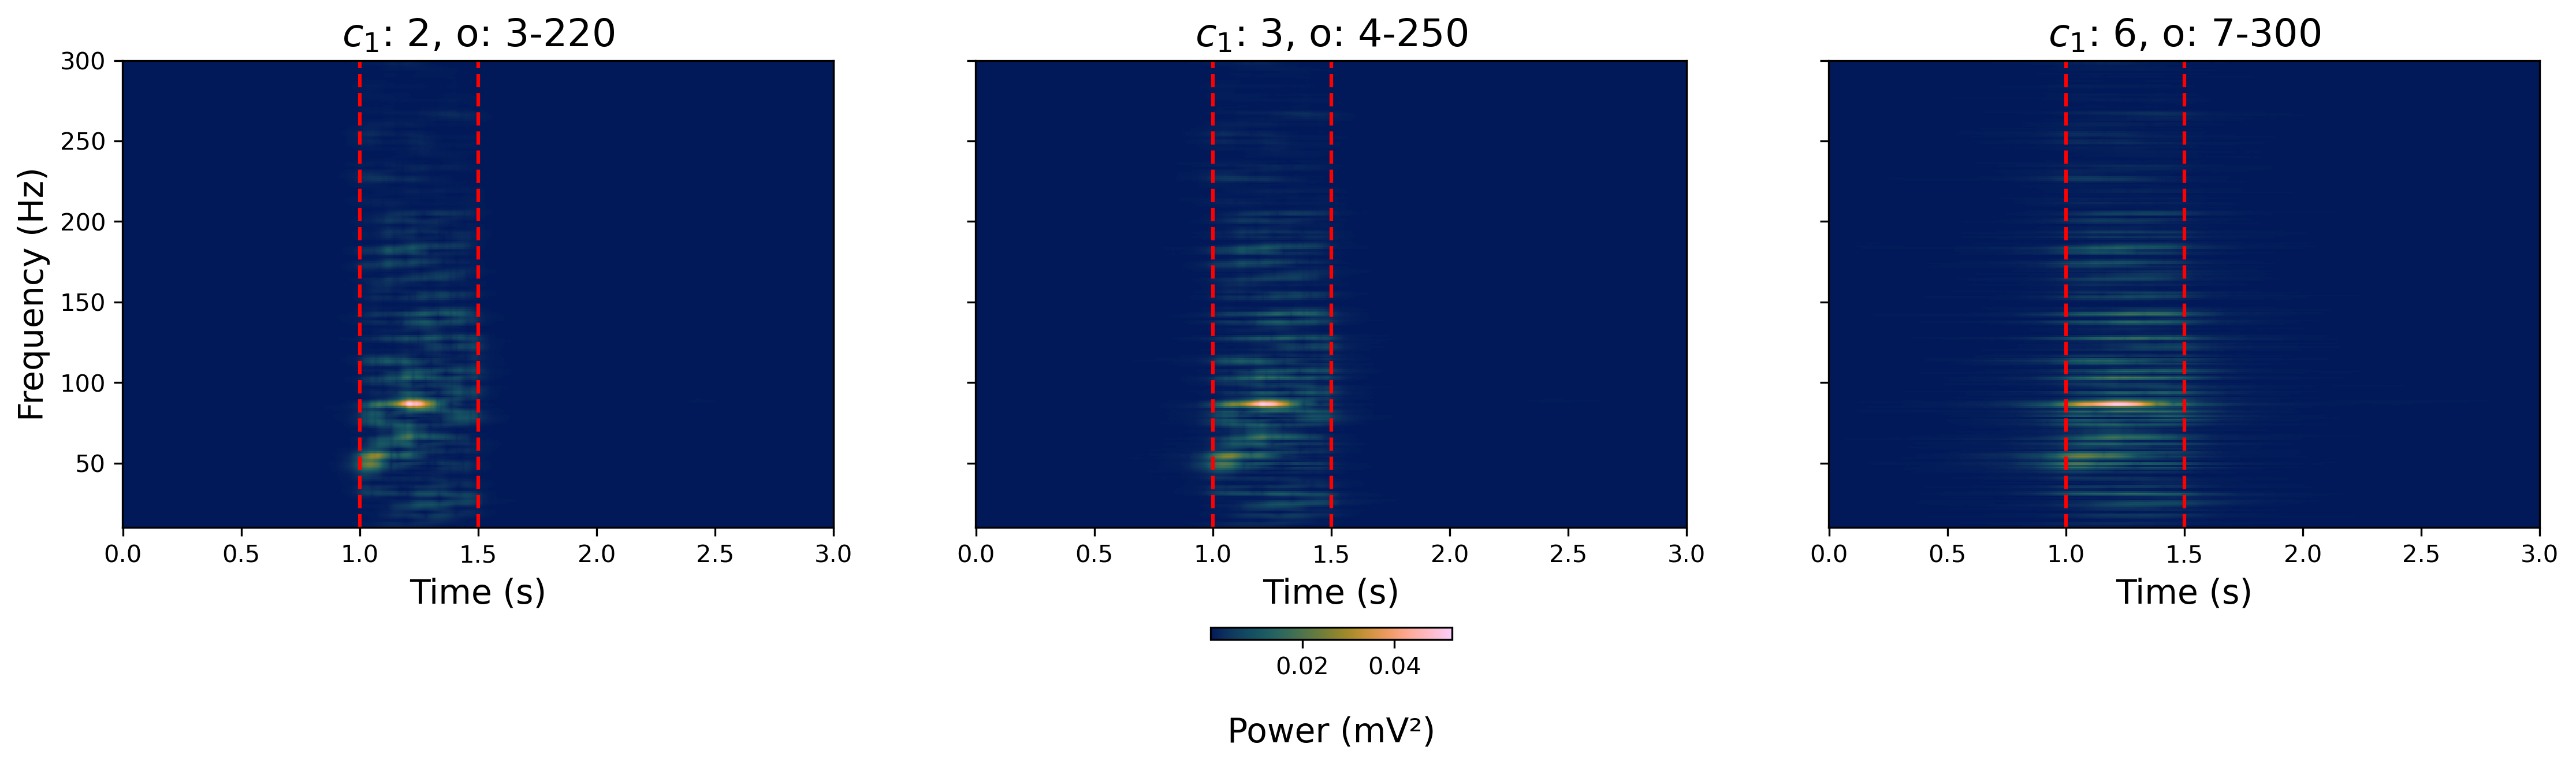

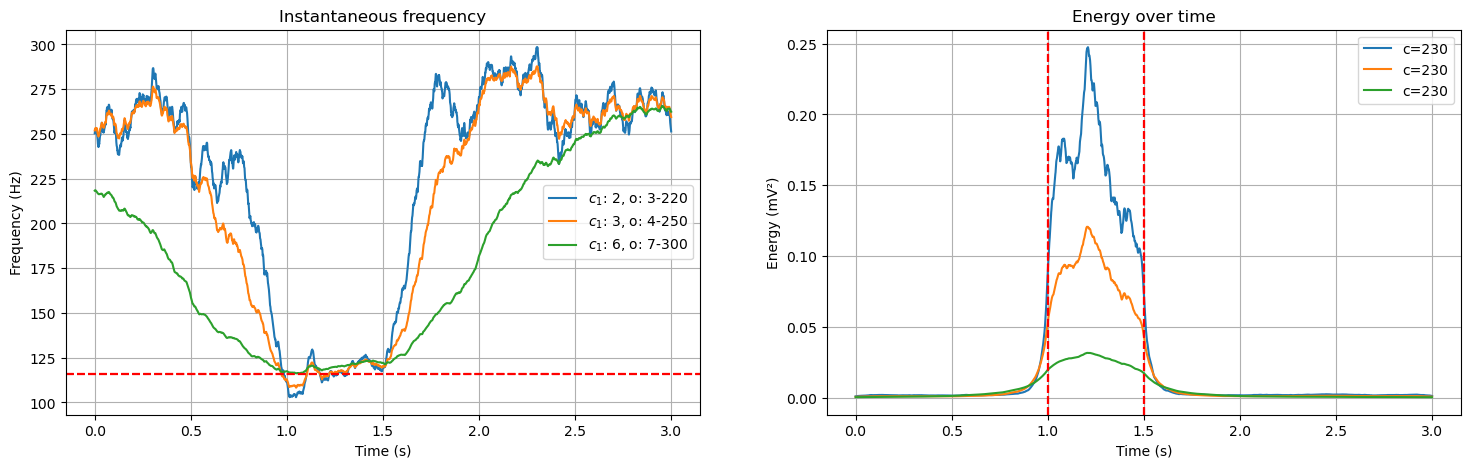

In [885]:
if plot_tf_representation:
    fig, ax = plt.subplots(ncols=len(params_wavelet), figsize=(18,5), dpi=300, sharey=True, sharex=True)
if plot_responses:
    fig_2, (ax_2_1, ax_2_2) = plt.subplots(1, 2, figsize=(18, 5))  
    
mae_superlet_f = []
std_superlet_f = []

mae_superlet_t = []
std_superlet_t = []

total_wavelet_superlet = []

for (i, (base_cycle, min_order, max_order)) in enumerate(zip(*params_superlet)):
    print(f'{i+1} parameter')
    
    wv, scalogram_slt = superlet.adaptive_superlet_transform(signal_15, freqs, sampling_freq=fs,
                                                         base_cycle=base_cycle, min_order=min_order,
                                                         max_order=max_order, mode="mul")
    
    if plot_tf_representation:
        mask_slt = (freqs >= f_min) & (freqs <= f_max)
        im = ax[i].pcolormesh(t, freqs[mask_slt], scalogram_slt[mask_slt, :], shading="auto", cmap=cmc.batlow)
        
        # im = ax[i].imshow(scalogram_slt[mask_slt,:], aspect='auto', cmap=cmc.batlow, interpolation="none", origin="lower",extent=[0, len(signal_15)/fs, freqs[mask_slt][0], freqs[mask_slt][-1]])
        ax[i].set_title(f"$c_1$: {base_cycle}, o: {min_order}-{max_order}", fontsize=fontsize_subtitle)
        ax[i].set_xlabel("Time (s)", fontsize=fontsize_labels)
        if i == 0:
            ax[i].set_ylabel("Frequency (Hz)", fontsize=fontsize_labels)
        else:
            ax[i].set_ylabel("")
        ax[i].set_ylim(f_min, f_max)
        ax[i].grid(False)
        
        ax[i].vlines([real_t_onset,real_t_offset], color='red', ymin=freqs[0], ymax=f_max, linestyle='--')
   
    # Energy in time is given directly by the scalogram
    first_indices = []
    last_indices = []
    
    # We compute one t_onset and t_offset for each frequency bin in the scalogram (that's why we don´t do energy_t = np.sum(scalogram_cwt, axis=0))

    for row in scalogram_slt:
        first_index, last_index = aux.find_plateau_region(row, burst_start, burst_duration, t, fs, plot_results=False)
        first_indices.append(first_index)
        last_indices.append(last_index)
        
    t_onset = t[first_indices]
    t_offset = t[last_indices]
    
    # Compute the instantaneous frequency
    instant_freq = np.sum(scalogram_slt * freqs[:, np.newaxis], axis=0) / np.sum(scalogram_slt, axis=0)
    
    instant_mean_freq_burst = instant_freq[start_idx:end_idx]
    
    if plot_responses:
        ax_2_1.plot(t, instant_freq, label=f"$c_1$: {base_cycle}, o: {min_order}-{max_order}")
        ax_2_1.set_xlabel("Time (s)")
        ax_2_1.set_ylabel("Frequency (Hz)")
        ax_2_1.legend()
        ax_2_1.grid(True)
        ax_2_1.axhline(MNF_ideal, color='red', linestyle='--')
        ax_2_1.set_title("Instantaneous frequency")
        
        ax_2_2.plot(t,  np.sum(scalogram_slt, axis=0), label=f"c={c}")
        ax_2_2.set_xlabel("Time (s)")
        ax_2_2.set_ylabel("Energy (mV²)")
        ax_2_2.legend()
        ax_2_2.grid(True)
        ax_2_2.axvline(real_t_onset, color='red', linestyle='--')
        ax_2_2.axvline(real_t_offset, color='red', linestyle='--')
        ax_2_2.set_title("Energy over time")
        
    # Compute MAE in frequency
    print(f'Estimated mean frequency: {np.mean(instant_mean_freq_burst)} Hz')
    mae_f, std_f = aux.calculate_mae(instant_mean_freq_burst, MNF_ideal)
    mae_superlet_f.append(mae_f)
    std_superlet_f.append(std_f)
    
    # Compute MAE in time
    print(f'Estimated onset = {np.mean(t_onset)} s, offset = {np.mean(t_offset)} s')
    mae_t, std_t = aux.calculate_mae((t_onset,t_offset), (real_t_onset,real_t_offset))
    mae_superlet_t.append(mae_t)
    std_superlet_t.append(std_t)
    print('---------------------------------------------------------------------------')
    
    total_wavelet_superlet.append(wv)
        
if plot_tf_representation: 
    cbar = fig.colorbar(pcm, ax=ax, orientation='horizontal', pad=0.15, shrink=0.1)
    
    cbar.set_label('Power (mV²)', rotation=0, labelpad=15, fontsize=fontsize_labels)
        
if save:
    fig.savefig(os.path.join(new_folder_path,f'scalogram_slt_{SNR}.png'), dpi=300, bbox_inches="tight")
    fig_2.savefig(os.path.join(new_folder_path,f'responses_slt_{SNR}.png'), dpi=300, bbox_inches="tight")
    

In [886]:
mae_superlet_f

[5.537582077182101, 4.117366391620564, 4.325316697494593]

In [887]:
mae_superlet_t

[0.16274822686014326, 0.18343729648323023, 0.29145922795913387]

# STFT

Estimated mean frequency: 126.66663339635767 Hz
Estimated onset = 0.9052582084551657 s, offset = 1.6130204526072125 s
---------------------------------------------------------------------------
Estimated mean frequency: 116.40331387023971 Hz
Estimated onset = 0.8722720973440545 s, offset = 1.6367130391081872 s
---------------------------------------------------------------------------
Estimated mean frequency: 116.42368235691859 Hz
Estimated onset = 0.8202706201267057 s, offset = 1.6912901285331383 s
---------------------------------------------------------------------------


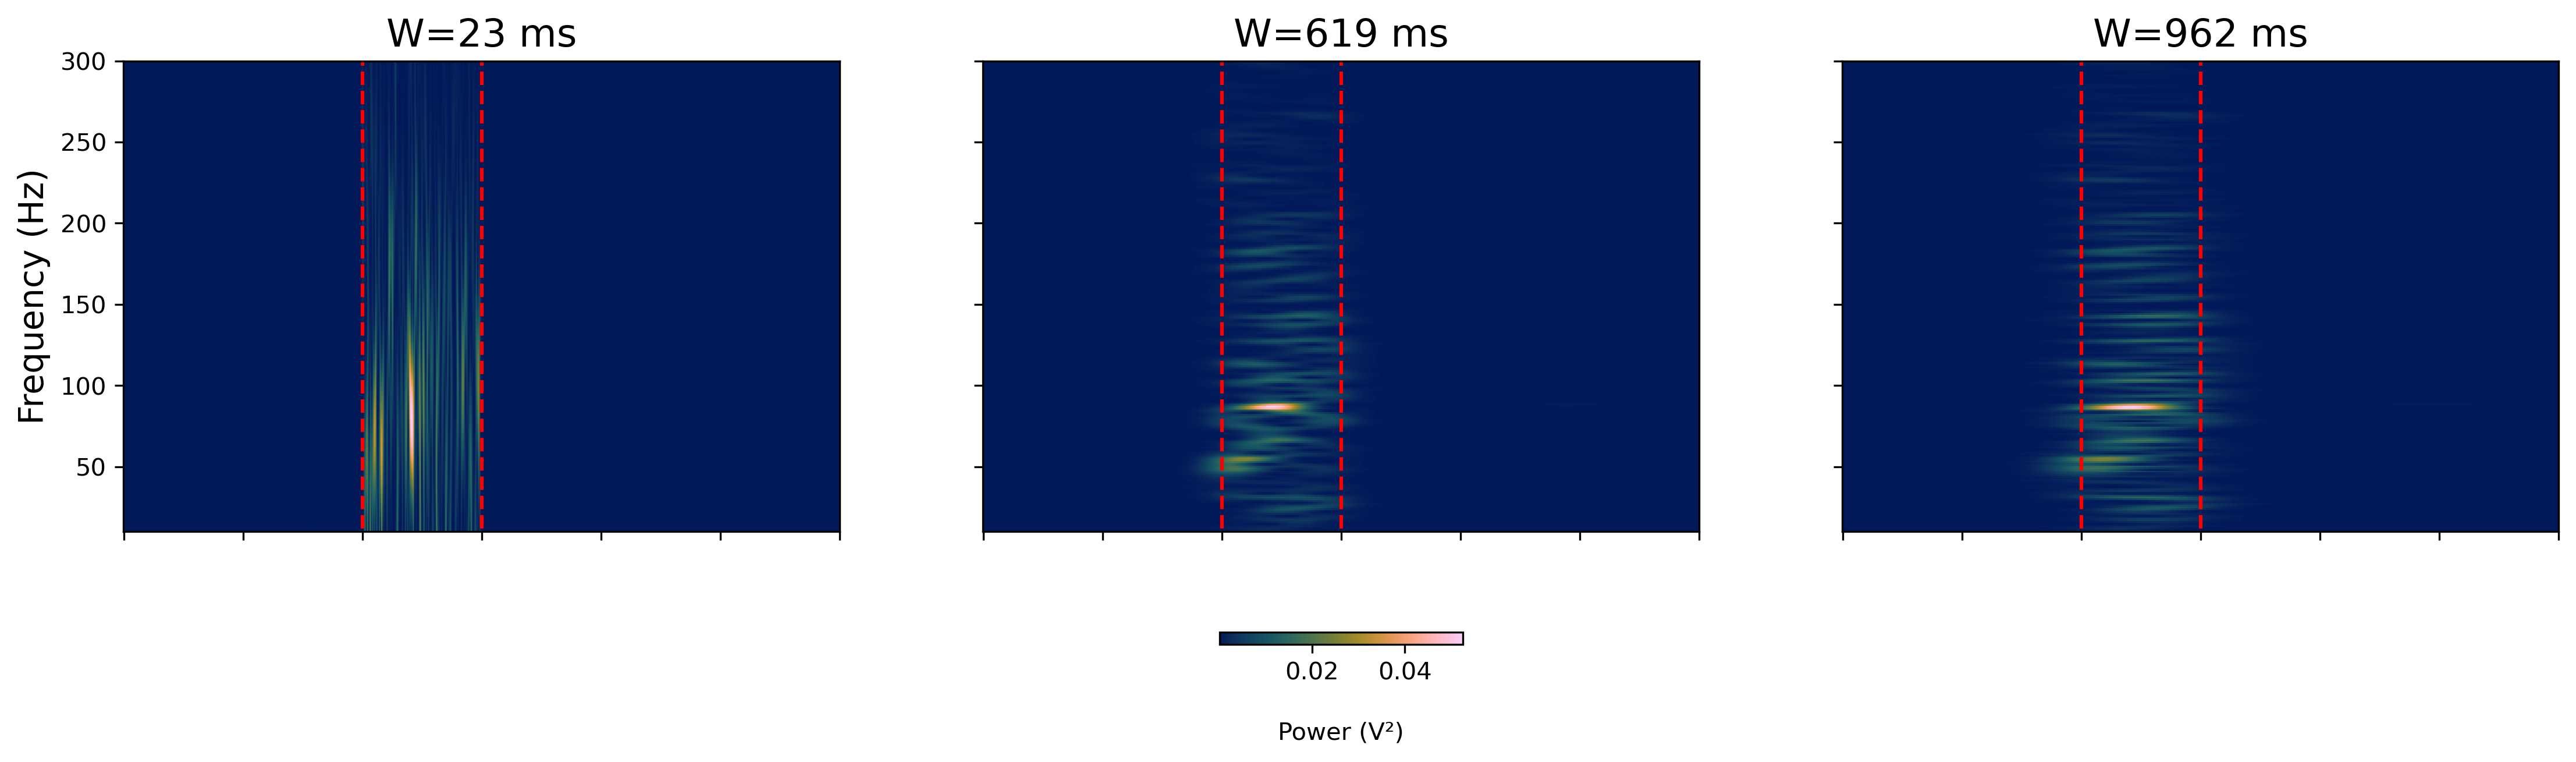

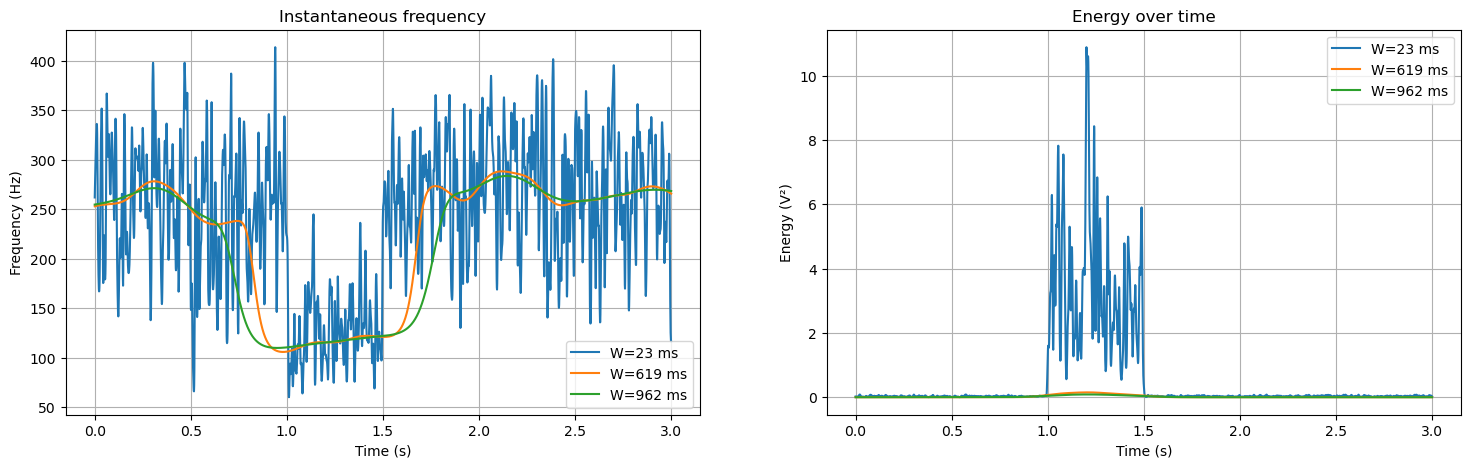

In [888]:
if plot_tf_representation:
    fig, ax = plt.subplots(ncols=len(windows_ms), figsize=(18,5), dpi=300, sharey=True, sharex=True)
if plot_responses:
    fig_2, (ax_2_1, ax_2_2) = plt.subplots(1, 2, figsize=(18, 5))  

mae_stft_f = []
std_stft_f = []

mae_stft_t = []
std_stft_t = []

cv_stft = []

total_time = []
total_freq = []

for i, w in enumerate(windows_ms):
    window = windows.blackman(w)
    
    nfft = 2 * (len(freqs))

    f_stft, t_stft, Zxx = stft(signal_15, fs=fs, window='blackman', nperseg=w, noverlap=w-1, nfft=nfft, detrend=False, return_onesided=True, boundary='zeros', padded=True, axis=-1, scaling='spectrum')

    spectrogram = np.abs(Zxx) ** 2
    
    if plot_tf_representation:
        mask_stft = f_stft <= f_max
        
        im = ax[i].pcolormesh(t_stft, f_stft[mask_stft], spectrogram[mask_stft, :], shading="auto", cmap=cmc.batlow)
        
        ax[i].set_title(f'W={w * 1000 // fs} ms', fontsize=fontsize_subtitle)
        if i == 0:
            ax[i].set_ylabel('Frequency (Hz)', fontsize=fontsize_labels)
        else: 
            ax[i].set_ylabel('')

        ax[i].set_ylim(f_min, f_max)
        
        ax[i].tick_params(axis='x', labelbottom=False, bottom=True)  # oculta etiquetas, deja palitos
        ax[i].vlines([real_t_onset, real_t_offset], color='red', ymin=f_stft[0], ymax=f_max, linestyle='--')

    instant_freq = np.sum(spectrogram * f_stft[:, np.newaxis], axis=0) / np.sum(spectrogram, axis=0)
    
    energia_temporal = spectrogram
    
    first_indices = []
    last_indices = []
    
    for row in energia_temporal:
        first_index, last_index = aux.find_plateau_region(row, burst_start, burst_duration, t_stft, fs, plot_results=False)
        first_indices.append(first_index)
        last_indices.append(last_index)
    
    t_onset = t_stft[first_indices]
    t_offset = t_stft[last_indices]

    instant_mean_freq_burst = instant_freq[start_idx:end_idx]

    if plot_responses:
        ax_2_1.plot(t_stft, instant_freq, label=f'W={w * 1000 // fs} ms')
        ax_2_1.set_xlabel("Time (s)")
        ax_2_1.set_ylabel("Frequency (Hz)")
        ax_2_1.legend()
        ax_2_1.grid(True)
        ax_2_1.set_title("Instantaneous frequency")
        
        ax_2_2.plot(t_stft,  np.sum(spectrogram, axis=0), label=f'W={w * 1000 // fs} ms')
        ax_2_2.set_xlabel("Time (s)")
        ax_2_2.set_ylabel("Energy (V²)")
        ax_2_2.legend()
        ax_2_2.grid(True)
        ax_2_2.set_title("Energy over time")

    #MAE in frequency
    print(f'Estimated mean frequency: {np.mean(instant_mean_freq_burst)} Hz')
    mae_f, std_f = aux.calculate_mae(instant_mean_freq_burst, MNF_ideal)
    mae_stft_f.append(mae_f)
    std_stft_f.append(std_f)
    
    #MAE in time
    print(f'Estimated onset = {np.mean(t_onset)} s, offset = {np.mean(t_offset)} s')
    mae_t, std_t = aux.calculate_mae((t_onset,t_offset), (real_t_onset,real_t_offset))
    mae_stft_t.append(mae_t)
    std_stft_t.append(std_t)
    print('---------------------------------------------------------------------------')

if plot_tf_representation:
    cbar = fig.colorbar(pcm, ax=ax, orientation='horizontal', pad=0.15, shrink=0.1)
    cbar.set_label('Power (V²)', rotation=0, labelpad=15)
    
if save:
    fig.savefig(os.path.join(new_folder_path,f'spectrogram_sst_{SNR}.png'), dpi=300, bbox_inches="tight")
    fig_2.savefig(os.path.join(new_folder_path,f'responses_sst_{SNR}.png'), dpi=300, bbox_inches="tight")

In [889]:
mae_stft_f

[29.06650185950527, 3.571498895716805, 2.9194663021116964]

In [890]:
mae_stft_t

[0.11002413803606238, 0.20352856968810917, 0.2315033732334308]

In [891]:
MAES_f['wavelet'].append(mae_wavelet_f)
MAES_f['stft'].append(mae_stft_f)
MAES_f['superlet'].append(mae_superlet_f)
MAES_f['std_wavelet'].append(std_wavelet_f)
MAES_f['std_stft'].append(std_stft_f)
MAES_f['std_superlet'].append(std_superlet_f)

In [892]:
MAES_t['wavelet'].append(mae_wavelet_t)
MAES_t['stft'].append(mae_stft_t)
MAES_t['superlet'].append(mae_superlet_t)
MAES_t['std_wavelet'].append(std_wavelet_t)
MAES_t['std_stft'].append(std_stft_t)
MAES_t['std_superlet'].append(std_superlet_t)

# WE REPEAT EVERYTHING WITH DIFFERENT SNR

In [893]:
signal_inf = burst_signal
SNR = 'Inf'

In [894]:
plot_tf_representation = False
plot_responses = False

In [895]:
if plot_tf_representation:
    fig, ax = plt.subplots(ncols=len(params_wavelet), figsize=(18,5), dpi=300, sharey=True, sharex=True)
if plot_responses:
    fig_2, (ax_2_1, ax_2_2) = plt.subplots(1, 2, figsize=(18, 5))  
    
mae_wavelet_f = []
std_wavelet_f = []

mae_wavelet_t = []
std_wavelet_t = []

for i, c in enumerate(params_wavelet):
    wavelet = f'cmor{c}-1.0'
    
    cwtmatr, f_cwt, physical_freqs = cwt.wavelet_transform(signal_inf,wavelet,freqs,fs)
    scalogram_cwt = np.abs(cwtmatr)**2
    
    if plot_tf_representation:
        mask_cwt = (f_cwt >= f_min) & (f_cwt <= f_max)
        
        pcm = ax[i].pcolormesh(t, f_cwt[mask_cwt], scalogram_cwt[mask_cwt,:], shading='gouraud', cmap=cmc.batlow)
        
        ax[i].set_title(f'c={c}', fontsize=fontsize_subtitle)
        if i == 0:
            ax[i].set_ylabel('Frequency (Hz)', fontsize=fontsize_labels)
        else:
            ax[i].set_ylabel('')
        
        ax[i].set_ylim(f_cwt[0], f_max)
        ax[i].tick_params(axis='x', labelbottom=False, bottom=True) 
        
    # Energy in time is given directly by the scalogram
    first_indices = []
    last_indices = []
    
    # We compute one t_onset and t_offset for each frequency bin in the scalogram (that's why we don´t do energy_t = np.sum(scalogram_cwt, axis=0))

    for row in scalogram_cwt:
        first_index, last_index = aux.find_plateau_region(row, burst_start, burst_duration, t, fs, plot_results=False)
        first_indices.append(first_index)
        last_indices.append(last_index)
        
    t_onset = t[first_indices]
    t_offset = t[last_indices]
    
    # Compute the instantaneous frequency
    instant_freq = np.sum(scalogram_cwt * f_cwt[:, np.newaxis], axis=0) / np.sum(scalogram_cwt, axis=0)
    
    instant_mean_freq_burst = instant_freq[start_idx:end_idx]
    
    if plot_responses:
        ax_2_1.plot(t, instant_freq, label=f"c={c}")
        ax_2_1.set_xlabel("Time (s)")
        ax_2_1.set_ylabel("Frequency (Hz)")
        ax_2_1.legend()
        ax_2_1.grid(True)
        ax_2_1.axhline(MNF_ideal, color='red', linestyle='--')
        ax_2_1.set_title("Instantaneous frequency")
        
        ax_2_2.plot(t,  np.sum(scalogram_cwt, axis=0), label=f"c={c}")
        ax_2_2.set_xlabel("Time (s)")
        ax_2_2.set_ylabel("Energy (mV²)")
        ax_2_2.legend()
        ax_2_2.grid(True)
        ax_2_2.axvline(real_t_onset, color='red', linestyle='--')
        ax_2_2.axvline(real_t_offset, color='red', linestyle='--')
        ax_2_2.set_title("Energy over time")
        
    # Compute MAE in frequency
    print(f'Estimated mean frequency: {np.mean(instant_mean_freq_burst)} Hz')
    mae_f, std_f = aux.calculate_mae(instant_mean_freq_burst, MNF_ideal)
    mae_wavelet_f.append(mae_f)
    std_wavelet_f.append(std_f)
    
    # Compute MAE in time
    print(f'Estimated onset = {np.mean(t_onset)} s, offset = {np.mean(t_offset)} s')
    mae_t, std_t = aux.calculate_mae((t_onset,t_offset), (real_t_onset,real_t_offset))
    mae_wavelet_t.append(mae_t)
    std_wavelet_t.append(std_t)
    print('---------------------------------------------------------------------------')
        
if plot_tf_representation: 
    cbar = fig.colorbar(pcm, ax=ax, orientation='horizontal', pad=0.15, shrink=0.1)
    
    cbar.set_label('Power (mV²)', rotation=0, labelpad=15, fontsize=fontsize_labels)
        
# if save:
#     fig.savefig(os.path.join(new_folder_path,f'scalogram_cwt_{SNR}.png'), dpi=300, bbox_inches="tight")
#     fig_2.savefig(os.path.join(new_folder_path,"responses_cwt_5.png"), dpi=300, bbox_inches="tight")
    

Estimated mean frequency: 115.8766445201713 Hz
Estimated onset = 0.9956797205714751 s, offset = 1.4805711443747966 s
---------------------------------------------------------------------------
Estimated mean frequency: 116.42623966503602 Hz
Estimated onset = 0.9946093495604038 s, offset = 1.4829751862178444 s
---------------------------------------------------------------------------
Estimated mean frequency: 117.38607049849607 Hz
Estimated onset = 0.9929551398160208 s, offset = 1.4847190705389126 s
---------------------------------------------------------------------------


In [896]:
if plot_tf_representation:
    fig, ax = plt.subplots(ncols=len(params_wavelet), figsize=(18,5), dpi=300, sharey=True, sharex=True)
if plot_responses:
    fig_2, (ax_2_1, ax_2_2) = plt.subplots(1, 2, figsize=(18, 5))  
    
mae_superlet_f = []
std_superlet_f = []

mae_superlet_t = []
std_superlet_t = []

for (i, (base_cycle, min_order, max_order)) in enumerate(zip(*params_superlet)):
    print(f'{i+1} parameter')

    # # New implementation gives the scalogram directly    
    _, scalogram_slt = superlet.adaptive_superlet_transform(signal_inf, freqs, sampling_freq=fs,
                                                         base_cycle=base_cycle, min_order=min_order,
                                                         max_order=max_order, mode="mul")
    
    if plot_tf_representation:
        mask_slt = (freqs >= f_min) & (freqs <= f_max)
        im = ax[i].pcolormesh(t, freqs[mask_slt], scalogram_slt[mask_slt, :], shading="auto", cmap=cmc.batlow)
        # im = ax[i].imshow(scalogram_slt[mask_slt,:], aspect='auto', cmap=cmc.batlow, interpolation="none", origin="lower",extent=[0, len(signal_inf)/fs, freqs[mask_slt][0], freqs[mask_slt][-1]])
        
        ax[i].set_title(f"$c_1$: {base_cycle}, o: {min_order}-{max_order}", fontsize=fontsize_subtitle)
        ax[i].set_xlabel("Time (s)", fontsize=fontsize_labels)
        if i == 0:
            ax[i].set_ylabel("Frequency (Hz)", fontsize=fontsize_labels)
        else:
            ax[i].set_ylabel("")
        ax[i].set_ylim(f_min, f_max)
        ax[i].grid(False)
   
    # Energy in time is given directly by the scalogram
    first_indices = []
    last_indices = []
    
    # We compute one t_onset and t_offset for each frequency bin in the scalogram (that's why we don´t do energy_t = np.sum(scalogram_cwt, axis=0))

    for row in scalogram_slt:
        first_index, last_index = aux.find_plateau_region(row, burst_start, burst_duration, t, fs, plot_results=False)
        first_indices.append(first_index)
        last_indices.append(last_index)
        
    # last_indices = [i for i in last_indices if i not in (0, 3072)]
    t_onset = t[first_indices]
    t_offset = t[last_indices]
    
    # Compute the instantaneous frequency
    instant_freq = np.sum(scalogram_slt * freqs[:, np.newaxis], axis=0) / np.sum(scalogram_slt, axis=0)
    
    instant_mean_freq_burst = instant_freq[start_idx:end_idx]
    
    if plot_responses:
        ax_2_1.plot(t, instant_freq, label=f"$c_1$: {base_cycle}, o: {min_order}-{max_order}")
        ax_2_1.set_xlabel("Time (s)")
        ax_2_1.set_ylabel("Frequency (Hz)")
        ax_2_1.legend()
        ax_2_1.grid(True)
        ax_2_1.axhline(MNF_ideal, color='red', linestyle='--')
        ax_2_1.set_title("Instantaneous frequency")
        
        ax_2_2.plot(t,  np.sum(scalogram_slt, axis=0), label=f"c={c}")
        ax_2_2.set_xlabel("Time (s)")
        ax_2_2.set_ylabel("Energy (mV²)")
        ax_2_2.legend()
        ax_2_2.grid(True)
        ax_2_2.axvline(real_t_onset, color='red', linestyle='--')
        ax_2_2.axvline(real_t_offset, color='red', linestyle='--')
        ax_2_2.set_title("Energy over time")
        
    # Compute MAE in frequency
    print(f'Estimated mean frequency: {np.mean(instant_mean_freq_burst)} Hz')
    mae_f, std_f = aux.calculate_mae(instant_mean_freq_burst, MNF_ideal)
    mae_superlet_f.append(mae_f)
    std_superlet_f.append(std_f)
    
    # Compute MAE in time
    print(f'Estimated onset = {np.mean(t_onset)} s, offset = {np.mean(t_offset)} s')
    mae_t, std_t = aux.calculate_mae((t_onset,t_offset), (real_t_onset,real_t_offset))
    mae_superlet_t.append(mae_t)
    std_superlet_t.append(std_t)
    print('---------------------------------------------------------------------------')
    
        
if plot_tf_representation: 
    cbar = fig.colorbar(pcm, ax=ax, orientation='horizontal', pad=0.15, shrink=0.1)
    
    cbar.set_label('Power (mV²)', rotation=0, labelpad=15, fontsize=fontsize_labels)
        
# if save:
#     fig.savefig(os.path.join(new_folder_path,f'scalogram_cwt_{SNR}.png'), dpi=300, bbox_inches="tight")
#     fig_2.savefig(os.path.join(new_folder_path,"responses_cwt_5.png"), dpi=300, bbox_inches="tight")
    

1 parameter
Estimated mean frequency: 115.60602035100138 Hz
Estimated onset = 1.012683546686747 s, offset = 1.4626419529469228 s
---------------------------------------------------------------------------
2 parameter
Estimated mean frequency: 116.16443344104904 Hz
Estimated onset = 0.9839991299658091 s, offset = 1.4993722779632042 s
---------------------------------------------------------------------------
3 parameter
Estimated mean frequency: 118.36021626825963 Hz
Estimated onset = 0.861379640182351 s, offset = 1.6289482253337675 s
---------------------------------------------------------------------------


In [897]:
if plot_tf_representation:
    fig, ax = plt.subplots(ncols=len(windows_ms), figsize=(18,5), dpi=300, sharey=True, sharex=True)
if plot_responses:
    fig_2, (ax_2_1, ax_2_2) = plt.subplots(1, 2, figsize=(18, 5))  

mae_stft_f = []
std_stft_f = []

mae_stft_t = []
std_stft_t = []

cv_stft = []

total_time = []
total_freq = []

for i, w in enumerate(windows_ms):
    window = windows.blackman(w)
    
    nfft = 2 * (len(freqs))

    f_stft, t_stft, Zxx = stft(signal_15, fs=fs, window='blackman', nperseg=w, noverlap=w-1, nfft=nfft, detrend=False, return_onesided=True, boundary='zeros', padded=True, axis=-1, scaling='spectrum')

    spectrogram = np.abs(Zxx) ** 2
    
    if plot_tf_representation:
        mask_stft = f_stft <= f_max
        
        im = ax[i].pcolormesh(t_stft, f_stft[mask_stft], spectrogram[mask_stft, :], shading="auto", cmap=cmc.batlow)
        
        ax[i].set_title(f'W={w * 1000 // fs} ms', fontsize=fontsize_subtitle)
        if i == 0:
            ax[i].set_ylabel('Frequency (Hz)', fontsize=fontsize_labels)
        else: 
            ax[i].set_ylabel('')

        ax[i].set_ylim(f_min, f_max)
        
        ax[i].tick_params(axis='x', labelbottom=False, bottom=True)  # oculta etiquetas, deja palitos
        ax[i].vlines([real_t_onset, real_t_offset], color='red', ymin=f_stft[0], ymax=f_max, linestyle='--')

    instant_freq = np.sum(spectrogram * f_stft[:, np.newaxis], axis=0) / np.sum(spectrogram, axis=0)
    
    energia_temporal = spectrogram
    
    first_indices = []
    last_indices = []
    
    for row in energia_temporal:
        first_index, last_index = aux.find_plateau_region(row, burst_start, burst_duration, t_stft, fs, plot_results=False)
        first_indices.append(first_index)
        last_indices.append(last_index)
    
    t_onset = t_stft[first_indices]
    t_offset = t_stft[last_indices]

    instant_mean_freq_burst = instant_freq[start_idx:end_idx]

    if plot_responses:
        ax_2_1.plot(t_stft, instant_freq, label=f'W={w * 1000 // fs} ms')
        ax_2_1.set_xlabel("Time (s)")
        ax_2_1.set_ylabel("Frequency (Hz)")
        ax_2_1.legend()
        ax_2_1.grid(True)
        ax_2_1.set_title("Instantaneous frequency")
        
        ax_2_2.plot(t_stft,  np.sum(spectrogram, axis=0), label=f'W={w * 1000 // fs} ms')
        ax_2_2.set_xlabel("Time (s)")
        ax_2_2.set_ylabel("Energy (V²)")
        ax_2_2.legend()
        ax_2_2.grid(True)
        ax_2_2.set_title("Energy over time")

    #MAE in frequency
    print(f'Estimated mean frequency: {np.mean(instant_mean_freq_burst)} Hz')
    mae_f, std_f = aux.calculate_mae(instant_mean_freq_burst, MNF_ideal)
    mae_stft_f.append(mae_f)
    std_stft_f.append(std_f)
    
    #MAE in time
    print(f'Estimated onset = {np.mean(t_onset)} s, offset = {np.mean(t_offset)} s')
    mae_t, std_t = aux.calculate_mae((t_onset,t_offset), (real_t_onset,real_t_offset))
    mae_stft_t.append(mae_t)
    std_stft_t.append(std_t)
    print('---------------------------------------------------------------------------')

if plot_tf_representation:
    cbar = fig.colorbar(pcm, ax=ax, orientation='horizontal', pad=0.15, shrink=0.1)
    cbar.set_label('Power (V²)', rotation=0, labelpad=15)
    
# if save:
#     fig.savefig(os.path.join(new_folder_path,f'spectrogram_sst_{SNR}.png'), dpi=300, bbox_inches="tight")
#     fig_2.savefig(os.path.join(new_folder_path,f'responses_sst_{SNR}.png'), dpi=300, bbox_inches="tight")

Estimated mean frequency: 126.66663339635767 Hz
Estimated onset = 0.9052582084551657 s, offset = 1.6130204526072125 s
---------------------------------------------------------------------------
Estimated mean frequency: 116.40331387023971 Hz
Estimated onset = 0.8722720973440545 s, offset = 1.6367130391081872 s
---------------------------------------------------------------------------
Estimated mean frequency: 116.42368235691859 Hz
Estimated onset = 0.8202706201267057 s, offset = 1.6912901285331383 s
---------------------------------------------------------------------------


In [898]:
MAES_f['wavelet'].append(mae_wavelet_f)
MAES_f['stft'].append(mae_stft_f)
MAES_f['superlet'].append(mae_superlet_f)
MAES_f['std_wavelet'].append(std_wavelet_f)
MAES_f['std_stft'].append(std_stft_f)
MAES_f['std_superlet'].append(std_superlet_f)

In [899]:
MAES_t['wavelet'].append(mae_wavelet_t)
MAES_t['stft'].append(mae_stft_t)
MAES_t['superlet'].append(mae_superlet_t)
MAES_t['std_wavelet'].append(std_wavelet_t)
MAES_t['std_stft'].append(std_stft_t)
MAES_t['std_superlet'].append(std_superlet_t)

# COMPARISON OF MAE IN FREQUENCY

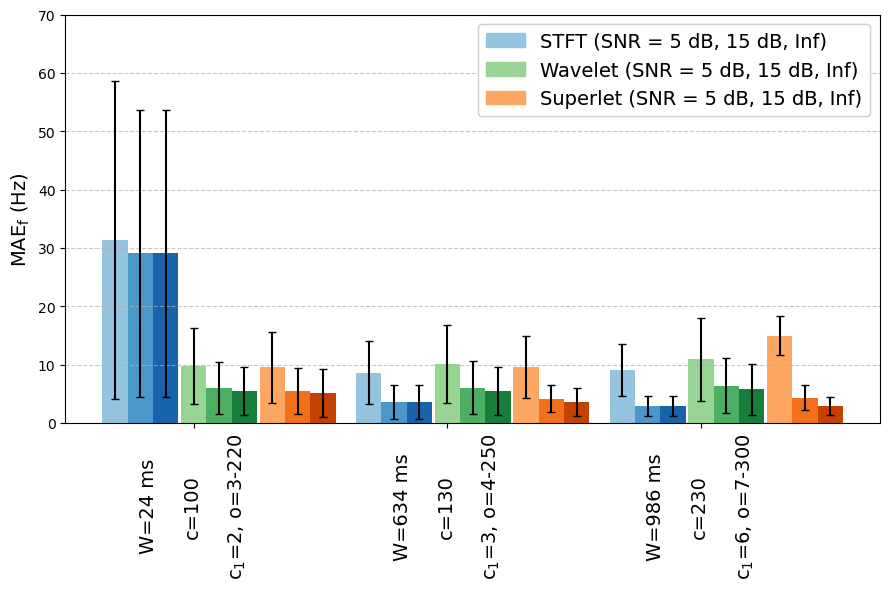

In [900]:
params_wavelet = params_wavelet
params_superlet = params_superlet
params_stft = windows_ms  # Tamaños de ventana en ms

# Datos MAE para cada técnica y SNR
mae_stft = MAES_f['stft']
std_stft = MAES_f['std_stft']

mae_wavelet = MAES_f['wavelet']
std_wavelet = MAES_f['std_wavelet']

mae_superlet = MAES_f['superlet']
std_superlet = MAES_f['std_superlet']

# Reordenar los niveles de SNR al orden deseado: 5 dB, 20 dB, Sin SNR
snr_labels = ["5 dB", "15 dB", "Inf"]
# mae_stft_2 = [mae_stft[1], mae_stft[0]]
mae_stft_2 = mae_stft
# std_stft_2 = [std_stft[1], std_stft[0]]
std_stft_2 = std_stft

# mae_wavelet_2 = [mae_wavelet[1], mae_wavelet[0]]
mae_wavelet_2 = mae_wavelet
# std_wavelet_2 = [std_wavelet[1], std_wavelet[0]]
std_wavelet_2 = std_wavelet

# mae_superlet_2 = [mae_superlet[1], mae_superlet[0]]
mae_superlet_2 = mae_superlet
# std_superlet_2 = [std_superlet[1], std_superlet[0]]
std_superlet_2 = std_superlet

# Configuración del gráfico
num_params = len(params_stft)  # Número de parámetros
num_snr = len(snr_labels)  # Número de niveles de ruido
x = np.arange(num_params)  # Posiciones base para cada grupo de parámetros
bar_width = 0.1  # Ancho de cada barra
group_width = bar_width * num_snr  # Espacio reservado para cada grupo de barras

# Tonalidades por nivel de ruido (ordenadas)
tonalidades = {
    "5 dB": 0.4,
    "15 dB": 0.6,
    "Inf": 0.8
}

# Colores base por metodología (asegurando correspondencia)
colores_base = {
    "STFT": plt.colormaps["Blues"],
    "Wavelet": plt.colormaps["Greens"],
    "Superlet": plt.colormaps["Oranges"],
}

# Crear el gráfico
plt.figure(figsize=(9, 6))

# Crear listas para la leyenda
handles = []
labels_legend = []

# Dibujar barras para cada técnica y SNR
for i, snr in enumerate(snr_labels):  # Iterar sobre niveles de SNR
    # Dibujar barras para STFT
    bar = plt.bar(
        x - 0.01 - group_width + i * bar_width,
        [np.array(mae_stft_2[i])[k] for k in range(num_params)],
        width=bar_width,
        color=colores_base["STFT"](tonalidades[snr]),
        label=f'STFT ({snr})'
    )
    handles.append(bar[0])

    plt.errorbar(
        x - 0.01 - group_width + i * bar_width,
        [np.array(mae_stft_2[i])[k] for k in range(num_params)],
        yerr=[np.array(std_stft_2[i])[k] for k in range(num_params)],
        fmt='none',
        ecolor='black',
        capsize=3
    )
    
    # Dibujar barras para Wavelet
    bar = plt.bar(
        x + i * bar_width,
        [np.array(mae_wavelet_2[i])[k] for k in range(num_params)],
        width=bar_width,
        color=colores_base["Wavelet"](tonalidades[snr]),
        label=f'CWT ({snr})'
    )
    handles.append(bar[0])

    plt.errorbar(
        x + i * bar_width,
        [np.array(mae_wavelet_2[i])[k] for k in range(num_params)],
        yerr=[np.array(std_wavelet_2[i])[k] for k in range(num_params)],
        fmt='none',
        ecolor='black',
        capsize=3
    )

    # Dibujar barras para Superlet
    bar = plt.bar(
        x + 0.01 + group_width + i * bar_width,
        [np.array(mae_superlet_2[i])[k] for k in range(num_params)],
        width=bar_width,
        color=colores_base["Superlet"](tonalidades[snr]),
        label=f'SLT ({snr})'
    )
    handles.append(bar[0])

    plt.errorbar(
        x + 0.01 + group_width + i * bar_width,
        [np.array(mae_superlet_2[i])[k] for k in range(num_params)],
        yerr=[np.array(std_superlet_2[i])[k] for k in range(num_params)],
        fmt='none',
        ecolor='black',
        capsize=3
    )

# Ordenar la leyenda agrupada por metodología
labels_legend = [f'STFT ({snr})' for snr in snr_labels] + \
                [f'CWT ({snr})' for snr in snr_labels] + \
                [f'SLT ({snr})' for snr in snr_labels]
handles = handles[:len(labels_legend)]

# Etiquetas para los grupos de parámetros con salto de línea adicional
labels = [
    f"W={p_stft} ms\n\nc={p_wavelet}\n\nc$_1$={p_superlet[0]}, o={p_superlet[1]}-{p_superlet[2]}"
    for p_wavelet, p_superlet, p_stft in zip(params_wavelet, zip(*params_superlet), params_stft)
]

from matplotlib.patches import Patch

leyenda_snr = [
    Patch(color=colores_base["STFT"](tonalidades["5 dB"]), label="STFT (SNR = 5 dB, 15 dB, Inf)"),
    # Patch(color=colores_base["STFT"](tonalidades["15 dB"]), label="STFT (SNR = 15 dB)"),
    # Patch(color=colores_base["STFT"](tonalidades["Inf"]), label="STFT (SNR = Inf)"),
    Patch(color=colores_base["Wavelet"](tonalidades["5 dB"]), label="Wavelet (SNR = 5 dB, 15 dB, Inf)"),
    # Patch(color=colores_base["Wavelet"](tonalidades["15 dB"]), label="Wavelet (SNR = 15 dB)"),
    # Patch(color=colores_base["Wavelet"](tonalidades["Inf"]), label="Wavelet (SNR = Inf)"),
    Patch(color=colores_base["Superlet"](tonalidades["5 dB"]), label="Superlet (SNR = 5 dB, 15 dB, Inf)"),
    # Patch(color=colores_base["Superlet"](tonalidades["15 dB"]), label="Superlet (SNR = 15 dB)"),
    # Patch(color=colores_base["Superlet"](tonalidades["Inf"]), label="Superlet (SNR = Inf)"),
]

# Configurar eje X y otros detalles
plt.xticks(x, labels, rotation=90, ha='center', fontsize=fontsize_labels)
# plt.yticks(np.arange(0, 46, 5))
plt.ylabel("$\mathregular{MAE_f}$ (Hz)", fontsize=fontsize_labels)
plt.ylim(0, 70)
#plt.legend(handles, labels_legend, fontsize=10, ncol=1)  # Leyenda agrupada
# plt.title('Comparison of MAE in frequency according to SNR', fontsize=fontsize_title)

plt.gca().add_artist(plt.legend(handles=leyenda_snr, loc='upper right', fontsize=fontsize_legend, title_fontsize=fontsize_legend + 2))

plt.grid(axis="y", linestyle="--", alpha=0.7)
# plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()

# Mostrar el gráfico

if save:
    plt.savefig(os.path.join(new_folder_path,"mae_frequency.png"), dpi=300, bbox_inches="tight")

# COMPARISON OF MAE IN TIME

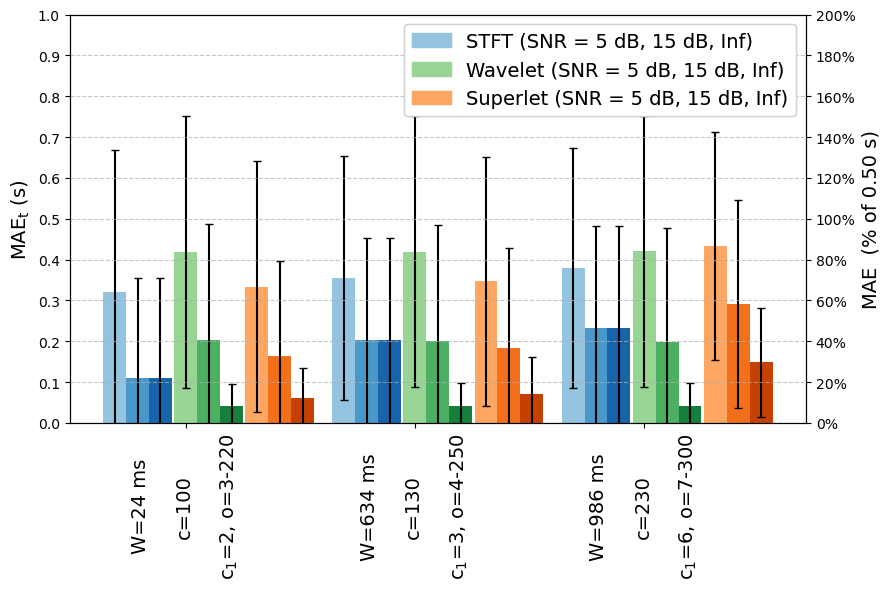

In [901]:
params_wavelet = params_wavelet
params_superlet = params_superlet
params_stft = windows_ms  # Tamaños de ventana en ms

# Datos MAE para cada técnica y SNR
mae_stft = MAES_t['stft']
std_stft = MAES_t['std_stft']

mae_wavelet = MAES_t['wavelet']
std_wavelet = MAES_t['std_wavelet']

mae_superlet = MAES_t['superlet']
std_superlet = MAES_t['std_superlet']

# Reordenar los niveles de SNR al orden deseado: 5 dB, 20 dB, Sin SNR
snr_labels = ["5 dB", "15 dB", "Inf"]
# mae_stft_2 = [mae_stft[1], mae_stft[0]]
mae_stft_2 = mae_stft
# std_stft_2 = [std_stft[1], std_stft[0]]
std_stft_2 = std_stft

# mae_wavelet_2 = [mae_wavelet[1], mae_wavelet[0]]
mae_wavelet_2 = mae_wavelet
# std_wavelet_2 = [std_wavelet[1], std_wavelet[0]]
std_wavelet_2 = std_wavelet

# mae_superlet_2 = [mae_superlet[1], mae_superlet[0]]
mae_superlet_2 = mae_superlet
# std_superlet_2 = [std_superlet[1], std_superlet[0]]
std_superlet_2 = std_superlet

# Configuración del gráfico
num_params = len(params_stft)  # Número de parámetros
num_snr = len(snr_labels)  # Número de niveles de ruido
x = np.arange(num_params)  # Posiciones base para cada grupo de parámetros
bar_width = 0.1  # Ancho de cada barra
group_width = bar_width * num_snr  # Espacio reservado para cada grupo de barras

# Tonalidades por nivel de ruido (ordenadas)
tonalidades = {
    "5 dB": 0.4,
    "15 dB": 0.6,
    "Inf": 0.8
}

# Colores base por metodología (asegurando correspondencia)
colores_base = {
    "STFT": plt.colormaps["Blues"],
    "Wavelet": plt.colormaps["Greens"],
    "Superlet": plt.colormaps["Oranges"],
}


# Crear el gráfico
plt.figure(figsize=(9, 6))
ax = plt.gca()

handles = []
labels_legend = []

for i, snr in enumerate(snr_labels):
    # STFT
    bar = ax.bar(
        x - 0.01 - group_width + i * bar_width,
        [np.array(mae_stft_2[i])[k] for k in range(num_params)],
        width=bar_width,
        color=colores_base["STFT"](tonalidades[snr]),
        label=f'STFT ({snr})'
    )
    handles.append(bar[0])
    
    ax.errorbar(
        x - 0.01 - group_width + i * bar_width,
        [np.array(mae_stft_2[i])[k] for k in range(num_params)],
        yerr=[np.array(std_stft_2[i])[k] for k in range(num_params)],
        fmt='none',
        ecolor='black',
        capsize=3
    )

    # Wavelet
    bar = ax.bar(
        x + i * bar_width,
        [np.array(mae_wavelet_2[i])[k] for k in range(num_params)],
        width=bar_width,
        color=colores_base["Wavelet"](tonalidades[snr]),
        label=f'Wavelet ({snr})'
    )
    handles.append(bar[0])
    
    ax.errorbar(
        x + i * bar_width,
        [np.array(mae_wavelet_2[i])[k] for k in range(num_params)],
        yerr=[np.array(std_wavelet_2[i])[k] for k in range(num_params)],
        fmt='none',
        ecolor='black',
        capsize=3
    )

    # Superlet
    bar = ax.bar(
        x + 0.01 + group_width + i * bar_width,
        [np.array(mae_superlet_2[i])[k] for k in range(num_params)],
        width=bar_width,
        color=colores_base["Superlet"](tonalidades[snr]),
        label=f'Superlet ({snr})'
    )
    handles.append(bar[0])
    
    ax.errorbar(
        x + 0.01 + group_width + i * bar_width,
        [np.array(mae_superlet_2[i])[k] for k in range(num_params)],
        yerr=[np.array(std_superlet_2[i])[k] for k in range(num_params)],
        fmt='none',
        ecolor='black',
        capsize=3
    )

# Etiquetas en el eje x
labels = [
    f"W={p_stft} ms\n\nc={p_wavelet}\n\nc$_1$={p_superlet[0]}, o={p_superlet[1]}-{p_superlet[2]}"
    for p_wavelet, p_superlet, p_stft in zip(params_wavelet, zip(*params_superlet), params_stft)
]

ax.set_xticks(x, labels, rotation=90, ha='center', fontsize=fontsize_labels)
ax.set_yticks(np.arange(0, 1.1, 0.1))
ax.set_ylabel("$\mathregular{MAE_t}$ (s)", fontsize=fontsize_labels)
ax.set_ylim(0, 1.0)

# 🔧 Eje derecho: % del burst_duration
yticks = [y for y in ax.get_yticks() if y >= 0]
ax_right = ax.twinx()
ax_right.set_ylim(ax.get_ylim())

percent_labels = [(y * 100) / burst_duration for y in yticks]
ax_right.set_yticks(yticks)
ax_right.set_yticklabels([f"{val:.0f}%" for val in percent_labels])
ax_right.set_ylabel(f"MAE  (% of {burst_duration:.2f} s)", fontsize=fontsize_labels)

# Leyenda de colores/SNR
plt.gca().add_artist(plt.legend(handles=leyenda_snr, loc='upper right', fontsize=fontsize_legend, title_fontsize=fontsize_legend + 2))
# plt.title('Comparison of MAE in time according to SNR', fontsize=fontsize_title)

plt.tight_layout()
# plt.grid(True)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.grid(axis="x", linestyle="--", alpha=0.7)

if save:
    plt.savefig(os.path.join(new_folder_path, "mae_time.png"), dpi=300, bbox_inches="tight")

plt.show()


# Save data

In [902]:
filename_1 = os.path.join(new_folder_path, "maes_f.txt")
filename_2 = os.path.join(new_folder_path, "maes_t.txt")

# Guardar el diccionario en un archivo de texto
with open(filename_1, "w", encoding="utf-8") as archivo:
    archivo.write(str(MAES_f))  # Convertimos el diccionario a string y lo guardamos
    
with open(filename_2, "w", encoding="utf-8") as archivo:
    archivo.write(str(MAES_t))  # Convertimos el diccionario a string y lo guardamos

print(f"Datos guardados en {filename_1}")
print(f"Datos guardados en {filename_2}")


Datos guardados en /Users/neuralrehabilitationgroup/PycharmProjects/Superlets-Marina/RESULTS/PAPER/0.5S/115.72 Hz/maes_f.txt
Datos guardados en /Users/neuralrehabilitationgroup/PycharmProjects/Superlets-Marina/RESULTS/PAPER/0.5S/115.72 Hz/maes_t.txt


# Compute resolution of SLT and CWT through Full-Width at Half Maximum (FWHM)

### Plot complex morlet wavelets with different center frequencies and bandwidths

In [903]:
compute_fwhm = False

In [904]:
if not compute_fwhm:
    sys.exit()  

SystemExit: 

# CWT

In [ ]:
import pywt
import scipy.interpolate as interp

In [ ]:
wavelets = [f"cmor{x:.1f}-{y:.1f}" for x, y in zip(params_wavelet,[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0])]

wavelets_cwt = []

fig, axs = plt.subplots(len(params_wavelet), figsize=(15, 10), sharex=True, sharey=True)
for ax, wavelet in zip(axs.flatten(), wavelets):
    [psi, x] = pywt.ContinuousWavelet(wavelet).wavefun(10)
    ax.plot(x, np.real(psi), label="real")
    ax.plot(x, np.imag(psi), label="imag")
    ax.set_title(wavelet)
    # ax.set_xlim([-5, 5])
    # ax.set_ylim([-0.8, 1])
    wavelets_cwt.append(psi)
ax.legend()
plt.suptitle("Complex Morlet Wavelets with different center frequencies and bandwidths")
plt.show()

In [ ]:
# Wavelet resolution
res_wavelet_t = []
res_wavelet_f = []

for wav in wavelets_cwt:
    # RESOLUTION IN TIME  
    fwhm_wavelet_t, onset_t, offset_t, half_max_t = aux.calculate_fwhm(np.abs(np.real(wav)))
    t_wv = np.linspace(0,len(np.abs(np.real(wav))),len(np.abs(np.real(wav))))
    res_wavelet_t.append(t_wv[offset_t]-t_wv[onset_t])  
    
    # RESOLUTION IN FREQUENCY
    psd, f1, MNF_2 = aux.periodogram_max_res(wav, fs, plot=False)
    
    f_interp = interp.interp1d(f1, psd, kind='cubic')
    
    x_new = np.linspace(f1.min(), f1.max(), 5000)
    y_new = f_interp(x_new)
    
    fwhm_wavelet_f, onset_f, offset_f, half_max_f = aux.calculate_fwhm(y_new)
    
    # Plot PSD
    plt.figure()
    plt.plot(x_new, y_new, '-')
    plt.xlim(0,20)
    plt.axvline(x_new[onset_f], linestyle='--', color='red')
    plt.axvline(x_new[offset_f], linestyle='--', color='red')
    plt.axhline(half_max_f, linestyle='--', color='green')
    plt.axvline(MNF_2, linestyle='--', color='orange')
    plt.text(5, 0, fwhm_wavelet_f)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Power Spectral Density")
    plt.title("PSD of the Morlet wavelet (CWT)")

    # plt.legend()
    plt.grid()
    plt.show()
    res_wavelet_f.append(x_new[offset_f]-x_new[onset_f])  

# SLT

In [ ]:
# Superlet resolution
res_superlet_t = []
res_superlet_f = []

for wav in total_wavelet_superlet:
    # RESOLUTION IN TIME     
    fwhm_superlet_t, onset_t, offset_t, half_max_t = aux.calculate_fwhm(np.abs(np.real(wav)))
    t_sl = np.linspace(0,len(np.abs(np.real(wav))),len(np.abs(np.real(wav))))
    res_superlet_t.append(t_sl[offset_t]-t_sl[onset_t])  

    # RESOLUTION IN FREQUENCY
    psd, f1, MNF_2 = aux.periodogram_max_res(wav, fs, plot=False)

    f_interp = interp.interp1d(f1, psd, kind='cubic')
    
    x_new = np.linspace(f1.min(), f1.max(), 5000)
    y_new = f_interp(x_new)
    
    fwhm_superlet_f, onset_f, offset_f, half_max_f = aux.calculate_fwhm(y_new)
    
    plt.figure()
    plt.plot(x_new, y_new, '-')
    # plt.xlim(490,510)
    plt.axvline(x_new[onset_f], linestyle='--', color='red')
    plt.axvline(x_new[offset_f], linestyle='--', color='red')
    plt.axhline(half_max_f, linestyle='--', color='green')
    plt.axvline(MNF_2, linestyle='--', color='orange')
    plt.text(495, 0, fwhm_superlet_f)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Power Spectral Density")
    plt.title("PSD of the Morlet wavelet (SLT)")
    #plt.xlim(120,140)
    plt.grid()
    plt.show()
    res_superlet_f.append(x_new[offset_f]-x_new[onset_f])  
    

In [ ]:
rayleigh_limit = 5.4

# Etiquetas para los grupos de parámetros con salto de línea adicional
labels = [
    f"c={p_wavelet}\nc$_1$={p_superlet[0]}, o={p_superlet[1]}-{p_superlet[2]}"
    for p_wavelet, p_superlet in zip(params_wavelet, zip(*params_superlet))
]

colores_base = {                                 
    "STFT": plt.colormaps["Blues"],              
    "Wavelet": plt.colormaps["Greens"],          
    "Superlet": plt.colormaps["Oranges"],        
}              

x = np.arange(1,len(params_wavelet)+1)

# plt.figure(figsize=(12, 8))
# plt.figure(figsize=(10, 8), constrained_layout=True)     

plt.figure(figsize=(10, 8))

# Primer gráfico (Frecuencia)
plt.subplot(2, 1, 1)
plt.plot(x, [r for r in res_wavelet_f], color=colores_base["Wavelet"](0.6), marker='o', linestyle='-', label="Wavelet (CWT)")
plt.plot(x, [r for r in res_superlet_f], color=colores_base["Superlet"](0.6), marker='o', linestyle='-', label="Superlets (SLT)")

plt.axhline(rayleigh_limit, color='k', linestyle='--', label="Freq. resolution limit (Rayleigh)")
# plt.xlabel("Cycles / Order")
plt.ylabel("Freq. response FWHM (Hz)", fontsize=fontsize_labels - 2)
plt.legend(fontsize=fontsize_legend)
# plt.ylim(0,30)
# plt.grid(True)

# Segundo gráfico (Tiempo)
plt.subplot(2, 1, 2)
plt.plot(x, [r for r in res_wavelet_t], color=colores_base["Wavelet"](0.6), marker='o', linestyle='-', label="Wavelet (CWT)")
plt.plot(x, [r for r in res_superlet_t], color=colores_base["Superlet"](0.6), marker='o', linestyle='-', label="Superlets (SLT)")

plt.axhline(1 / 3, color='k', linestyle='--', label="Temporal resolution limit")
# plt.xlabel("Cycles / Order")
plt.ylabel("Time response FWHM (s)", fontsize=fontsize_labels-2)
# plt.legend(fontsize=fontsize_legend)
# plt.ylim(0,1100)

# Ajuste de los xticks para ambos subgráficos
for ax in plt.gcf().get_axes():
    ax.set_xticks(x)  # Establecer los valores de los ticks
    ax.set_xticklabels(labels, rotation=90, ha='center', fontsize=fontsize_labels)  # Establecer las etiquetas con el formato deseado

# Ajustar el diseño
plt.tight_layout()
# plt.subplots_adjust(left=0.15, hspace=0.1)
# plt.grid(True)
plt.show()